# Simulasi: SAC-Based Gamma Controller + Network-Markowitz Portfolio
## Model: Comp_Static_Gamma0 | Comp_Static_Gamma1 | Comp_Static_Gamma2 | E2_NoMarket | Classic-MV
## Evaluasi 4 Metrik: Sharpe | Sortino | Calmar | CVaR (95%)

**Perbaikan dari versi sebelumnya:**

| # | Masalah | Fix |
|---|---------|-----|
| 1 | Single seed (SEEDS=[42]) — hasil tidak reliabel secara statistik | **Multi-seed: [42, 123, 77]** — mean ± std dilaporkan |
| 2 | TRAIN_STEPS=2000 — terlalu kecil untuk SAC konvergen | **TRAIN_STEPS=10000** + learning curve monitoring |
| 3 | Tidak ada uji signifikansi statistik | **Wilcoxon signed-rank test** antar konfigurasi utama |
| 4 | Baseline terlalu lemah (Classic-MV tanpa pembanding lain) | Tambah **Equal Risk Contribution (ERC)** sebagai baseline |
| 5 | Tidak ada learning curve tracking | **SAC reward tracking** per episode disimpan & divisualisasi |
| 6 | Tidak ada robustness check periode | **Walk-forward validation** (rolling 3 windows) pada test set |

**Perbaikan tambahan (versi ini):**

| # | Masalah | Fix |
|---|---------|-----|
| 7 | Upper bound bobot 40% hanya di `_solve_weights` — tidak konsisten dengan ERC | **Semua model pakai bounds (0, 1.0)** — long-only tanpa upper cap |
| 8 | Classic-MV memakai RMT filter dan shared solver — tidak merepresentasikan Markowitz klasik | **Fungsi terpisah `compute_classic_mv_weights()`** dengan sample covariance biasa |
| 9 | Perbandingan tidak apples-to-apples karena perbedaan kovarians estimasi | Classic-MV kini pakai `np.cov()` murni, tanpa RMT denoising |



## Setup & Install

In [26]:
#%pip install stable_baselines3[extra] scipy

## Global Settings & Imports

In [27]:
# ================================================================
# GLOBAL SETTINGS — THESIS-READY VERSION
# ================================================================
SEEDS         = [42, 123, 77]    # FIX 1: Multi-seed untuk reliabilitas statistik
TRAIN_STEPS   = 25000            # FIX 2: SAC butuh minimal ~5000-10000 steps
GAMMA_CENTER  = 0
SET_WINDOW    = 30
SET_REBALANCE = 7
REWARD_WINDOW = 20
CVAR_LEVEL    = 0.95
STAT_ALPHA    = 0.05             # FIX 3: significance level untuk uji statistik

# Definisi eksperimen ablation
ABLATION_CONFIGS = {
    # --- Baseline: Static Gamma ---
    'Comp_Static_Gamma0' : {'use_network': True,  'use_market': False, 'extra_features': [], 'static_gamma': 0.0},
    'Comp_Static_Gamma1' : {'use_network': True,  'use_market': False, 'extra_features': [], 'static_gamma': 1.0},
    'Comp_Static_Gamma2' : {'use_network': True,  'use_market': False, 'extra_features': [], 'static_gamma': 2.0},

    # --- Proposed: E2_NoMarket (Full Network Features, SAC Dynamic) ---
    'E2_NoMarket'        : {'use_network': True,  'use_market': False, 'extra_features': []},
}

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import networkx as nx
import seaborn as sns
import warnings
import os
from scipy import stats
from scipy.optimize import minimize
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import SAC
from stable_baselines3.common.callbacks import BaseCallback

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
os.makedirs('ablation_results_thesis', exist_ok=True)

print('Libraries loaded.')
print(f'Ablation configs: {list(ABLATION_CONFIGS.keys())}')
print(f'SEEDS={SEEDS} | TRAIN_STEPS={TRAIN_STEPS} | CVaR level={CVAR_LEVEL*100:.0f}%')


Libraries loaded.
Ablation configs: ['Comp_Static_Gamma0', 'Comp_Static_Gamma1', 'Comp_Static_Gamma2', 'E2_NoMarket']
SEEDS=[42, 123, 77] | TRAIN_STEPS=25000 | CVaR level=95%


## Phase 1: Data Preparation

In [28]:
file_data = 'crypto_data_real.xlsx'

def load_and_split(filename, train_split=0.7):
    df = pd.read_excel(filename, sheet_name='Returns', index_col=0)
    df.index = pd.to_datetime(df.index)
    assets = list(df.columns)
    if 'USDT' in assets:
        assets.remove('USDT')
        print('USDT removed from assets.')
    assets.sort()
    df = df[assets]
    split_idx = int(len(df) * train_split)
    return df.iloc[:split_idx], df.iloc[split_idx:], assets

ret_train, ret_test, assets = load_and_split(file_data)

print(f'Assets ({len(assets)}): {assets}')
print(f'Training : {ret_train.index[0].date()} – {ret_train.index[-1].date()} ({len(ret_train)} days)')
print(f'Testing  : {ret_test.index[0].date()} – {ret_test.index[-1].date()} ({len(ret_test)} days)')


USDT removed from assets.
Assets (9): ['BCH', 'BNB', 'BTC', 'EOS', 'ETH', 'LTC', 'TRX', 'XLM', 'XRP']
Training : 2017-09-15 – 2019-03-02 (534 days)
Testing  : 2019-03-03 – 2019-10-17 (229 days)


## Phase 2: Core Functions

Fungsi inti portofolio, 4 metrik evaluasi, dan helper visualisasi.

In [29]:
# ────────────────────────────────────────────────────────────────
# 2A. Portfolio Optimization
# ────────────────────────────────────────────────────────────────

def apply_rmt_filter(returns_window):
    """Random Matrix Theory filter untuk denoising matriks korelasi."""
    T, N = returns_window.shape
    corr_mat = returns_window.corr().fillna(0).values
    eigenvalues, eigenvectors = np.linalg.eigh(corr_mat)
    Q = T / N
    lambda_max = (1 + np.sqrt(1 / Q)) ** 2
    n_signal = np.sum(eigenvalues >= lambda_max)
    if n_signal == 0:
        eigenvalues[:-1] = 0
    else:
        eigenvalues[eigenvalues < lambda_max] = 0
    corr_denoised = eigenvectors @ np.diag(eigenvalues) @ eigenvectors.T
    np.fill_diagonal(corr_denoised, 1)
    return corr_denoised


def _solve_weights(cov_f, cent_vec, mu, gamma, n_assets):
    """Solver SLSQP. Fallback ke equal-weight jika infeasible."""
    fun = lambda w: w.T @ cov_f @ w + gamma * np.sum(cent_vec * w)
    cons_with_ret = (
        {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
        {'type': 'ineq', 'fun': lambda w: np.dot(w, mu) - np.mean(mu)},
    )
    cons_no_ret = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1},)
    bounds = tuple((0, 1.0) for _ in range(n_assets))  # FIX 7: long-only tanpa upper cap, konsisten dengan ERC
    w0 = np.ones(n_assets) / n_assets
    res = minimize(fun, w0, method='SLSQP', bounds=bounds, constraints=cons_with_ret)
    if res.success:
        return res.x
    res2 = minimize(fun, w0, method='SLSQP', bounds=bounds, constraints=cons_no_ret)
    return res2.x if res2.success else w0


def _build_mst_centrality(N, corr_f):
    """Bangun MST dan hitung eigenvector centrality. max_iter=300, fallback ke degree_centrality."""
    dist_mat = np.sqrt(np.maximum(0, 2 * (1 - corr_f)))
    G_full = nx.from_numpy_array(dist_mat)
    mst = nx.minimum_spanning_tree(G_full)
    try:
        centrality = nx.eigenvector_centrality(mst, max_iter=300)
        cent_vec = np.array([centrality[i] for i in range(N)])
    except Exception:
        cent_vec = np.array(list(nx.degree_centrality(mst).values()))
    return mst, cent_vec


def get_centrality_weights(returns_window, gamma=1.0):
    """Full recompute (dipakai untuk test set yang tidak ada di cache)."""
    T, N = returns_window.shape
    mu     = returns_window.mean().values
    sigma  = returns_window.std().values
    corr_f = apply_rmt_filter(returns_window)
    cov_f  = np.outer(sigma, sigma) * corr_f + np.eye(N) * 1e-8
    _, cent_vec = _build_mst_centrality(N, corr_f)
    return _solve_weights(cov_f, cent_vec, mu, gamma, N)


def fast_centrality_weights(cov_f, cent_vec, mu, gamma):
    """Hitung bobot menggunakan cache."""
    return _solve_weights(cov_f, cent_vec, mu, gamma, len(mu))


# ────────────────────────────────────────────────────────────────
# FIX 8 & 9: Classic Markowitz — fungsi terpisah, sample covariance murni
# ────────────────────────────────────────────────────────────────

def compute_classic_mv_weights(returns_window):
    """
    Classic Markowitz Mean-Variance Optimization (Pure).

    Perbedaan dari _solve_weights / Network-Markowitz:
    - Menggunakan sample covariance matrix biasa (np.cov), BUKAN RMT-filtered.
    - Tidak ada regularisasi jaringan (cent_vec = 0, gamma = 0).
    - Bounds: (0, 1.0) — long-only tanpa upper cap.
    - Objective: minimize w'Σw  subject to: sum(w)=1, E[rp]>=mean(μ), w>=0.

    Ini adalah implementasi Markowitz (1952) yang paling dekat ke bentuk aslinya,
    dan digunakan sebagai baseline perbandingan yang bersih terhadap model usulan.
    """
    T, N = returns_window.shape
    mu   = returns_window.mean().values
    # Sample covariance matrix murni — tanpa RMT filter
    cov  = np.cov(returns_window.values.T) + np.eye(N) * 1e-8  # regularisasi minimal

    w0     = np.ones(N) / N
    bounds = tuple((0.0, 1.0) for _ in range(N))

    fun = lambda w: w @ cov @ w  # minimize portfolio variance

    cons_with_ret = (
        {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
        {'type': 'ineq', 'fun': lambda w: np.dot(w, mu) - np.mean(mu)},
    )
    cons_no_ret = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1},)

    res = minimize(fun, w0, method='SLSQP', bounds=bounds, constraints=cons_with_ret)
    if res.success:
        return res.x
    res2 = minimize(fun, w0, method='SLSQP', bounds=bounds, constraints=cons_no_ret)
    return res2.x if res2.success else w0


# ────────────────────────────────────────────────────────────────
# 2B. Equal Risk Contribution (ERC) — FIX 4: Baseline tambahan
# ────────────────────────────────────────────────────────────────

def compute_erc_weights(cov_matrix, tol=1e-8):
    """
    Equal Risk Contribution (Risk Parity) portfolio.
    Setiap aset berkontribusi equal terhadap total portfolio risk.
    Lebih robust dari Classic-MV karena tidak perlu estimasi expected return.
    """
    n = cov_matrix.shape[0]
    w0 = np.ones(n) / n

    def risk_budget_objective(w):
        port_var = w @ cov_matrix @ w
        marginal_contrib = cov_matrix @ w
        risk_contrib = w * marginal_contrib / (port_var + tol)
        target = np.ones(n) / n
        return np.sum((risk_contrib - target) ** 2)

    cons = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1},)
    bounds = tuple((0.0, 1.0) for _ in range(n))
    res = minimize(risk_budget_objective, w0, method='SLSQP',
                   bounds=bounds, constraints=cons,
                   options={'ftol': 1e-10, 'maxiter': 500})
    return res.x if res.success else w0


# ────────────────────────────────────────────────────────────────
# 2C. Return / Drawdown helpers
# ────────────────────────────────────────────────────────────────

def _compute_drawdown(arr):
    cumulative = (1 + arr).cumprod()
    peak = np.maximum.accumulate(cumulative)
    return (cumulative - peak) / peak, cumulative


def calculate_annualized_return(ret_series, periods_per_year=252):
    arr = np.array(ret_series)
    n = len(arr)
    if n == 0: return np.nan
    total = (1 + arr).prod()
    if total <= 0: return np.nan
    return total ** (periods_per_year / n) - 1


# ────────────────────────────────────────────────────────────────
# 2D. 4 Metrik Evaluasi Utama Tesis
# ────────────────────────────────────────────────────────────────

def calculate_sharpe_ratio(ret_series, periods_per_year=252):
    arr = np.array(ret_series)
    ann_ret = calculate_annualized_return(arr, periods_per_year)
    ann_vol = arr.std() * np.sqrt(periods_per_year)
    if ann_vol <= 0 or np.isnan(ann_ret): return 0.0
    return ann_ret / ann_vol


def calculate_sortino_ratio(ret_series, periods_per_year=252, mar=0.0):
    arr = np.array(ret_series)
    ann_ret = calculate_annualized_return(arr, periods_per_year)
    downside = arr[arr < mar]
    if len(downside) == 0: return 0.0
    downside_dev = np.std(downside) * np.sqrt(periods_per_year)
    if downside_dev <= 0 or np.isnan(ann_ret): return 0.0
    return ann_ret / downside_dev


def calculate_calmar_ratio(ret_series, periods_per_year=252):
    arr = np.array(ret_series)
    ann_ret = calculate_annualized_return(arr, periods_per_year)
    drawdown, _ = _compute_drawdown(arr)
    max_dd = drawdown.min()
    if max_dd == 0 or np.isnan(ann_ret): return 0.0
    return ann_ret / abs(max_dd)


def calculate_cvar(ret_series, confidence=0.95):
    arr = np.array(ret_series)
    var = np.percentile(arr, (1 - confidence) * 100)
    tail_losses = arr[arr <= var]
    if len(tail_losses) == 0: return 0.0
    return float(-np.mean(tail_losses))


def calculate_all_metrics(ret_series, cvar_level=0.95, periods_per_year=252):
    arr = np.array(ret_series)
    ann_ret = calculate_annualized_return(arr, periods_per_year)
    ann_vol = arr.std() * np.sqrt(periods_per_year)
    total_ret = (1 + arr).prod() - 1
    drawdown, _ = _compute_drawdown(arr)
    max_dd = drawdown.min()
    downside = arr[arr < 0]
    down_std = np.std(downside) * np.sqrt(periods_per_year) if len(downside) > 0 else 0.0
    return {
        'Sharpe Ratio'    : calculate_sharpe_ratio(arr, periods_per_year),
        'Sortino Ratio'   : calculate_sortino_ratio(arr, periods_per_year),
        'Calmar Ratio'    : calculate_calmar_ratio(arr, periods_per_year),
        'CVaR (95%)'      : calculate_cvar(arr, cvar_level),
        'Total Return'    : total_ret,
        'Ann. Return'     : ann_ret,
        'Ann. Volatility' : ann_vol,
        'Downside Std'    : down_std,
        'Max Drawdown'    : max_dd,
    }


# ────────────────────────────────────────────────────────────────
# 2E. Shared Visualisation Helpers
# ────────────────────────────────────────────────────────────────

ABLATION_COLORS = {
    'E2_NoMarket'        : '#FF9800',
    'Comp_Static_Gamma0' : '#9E9E9E',
    'Comp_Static_Gamma1' : '#795548',
    'Comp_Static_Gamma2' : '#607D8B',
    'Classic-MV'         : '#9C27B0',
}

MAIN_EXPS = ['Comp_Static_Gamma0', 'Comp_Static_Gamma1', 'Comp_Static_Gamma2',
             'E2_NoMarket', 'Classic-MV']
LOO_EXPS  = ['E2_NoMarket']  # LOO ablation tidak disertakan dalam simulasi ini

METRIC_KEY = {
    'Sharpe Ratio' : 'SharpeRatio',
    'Sortino Ratio': 'SortinoRatio',
    'Calmar Ratio' : 'CalmarRatio',
    'CVaR (95%)'   : 'CVaR95pct',
}
FOUR_METRICS = list(METRIC_KEY.keys())


def _style_table(tbl, col_labels, n_rows):
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8)
    for j in range(len(col_labels)):
        tbl[0, j].set_facecolor('#1565C0')
        tbl[0, j].set_text_props(color='white', fontweight='bold')
    for i in range(1, n_rows + 1):
        fc = '#E3F2FD' if i % 2 == 0 else 'white'
        for j in range(len(col_labels)):
            tbl[i, j].set_facecolor(fc)


def _plot_metric_bars(ax, summary_df, exp_ids, colors, mean_col, std_col,
                      label, lower_better, short_labels=True):
    vals = summary_df.loc[exp_ids, mean_col].values
    errs = summary_df.loc[exp_ids, std_col].values
    bars = ax.bar(range(len(exp_ids)), vals, yerr=errs,
                  color=colors, edgecolor='white', capsize=3, alpha=0.85)
    best_idx = np.argmin(vals) if lower_better else np.argmax(vals)
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(2.5)
    ax.axhline(0, color='black', linewidth=0.6)
    ax.set_xticks(range(len(exp_ids)))
    xlabels = ([e.split('_')[0] for e in exp_ids] if short_labels
               else [e.replace('_', '\n') for e in exp_ids])
    ax.set_xticklabels(xlabels, fontsize=7)
    ax.set_title(label, fontsize=9, fontweight='bold')
    ax.set_ylabel(label, fontsize=8)
    return bars, vals, errs


def _mean_cumret(ablation_results, exp_id, period):
    return pd.concat(
        [ablation_results[exp_id][period][s] for s in SEEDS], axis=1
    ).mean(axis=1)


def _build_heatmap_data(summary_df, exp_ids, period):
    metric_cols = [(f'{METRIC_KEY[m]}_{period}_Mean', m.split()[0]) for m in FOUR_METRICS]
    metric_cols[-1] = (f'CVaR95pct_{period}_Mean', 'CVaR(95%)')
    heatmap_data = pd.DataFrame(
        {lbl: summary_df[col] for col, lbl in metric_cols},
        index=exp_ids
    ).astype(float)
    heatmap_norm = heatmap_data.copy()
    for col in ['Sharpe', 'Sortino', 'Calmar']:
        mn, mx = heatmap_norm[col].min(), heatmap_norm[col].max()
        heatmap_norm[col] = (heatmap_norm[col] - mn) / (mx - mn + 1e-8)
    mn, mx = heatmap_norm['CVaR(95%)'].min(), heatmap_norm['CVaR(95%)'].max()
    heatmap_norm['CVaR(95%)'] = 1 - (heatmap_norm['CVaR(95%)'] - mn) / (mx - mn + 1e-8)
    return heatmap_data, heatmap_norm


print('Core functions + 4 metrik evaluasi + ERC baseline + visualisation helpers defined.')


Core functions + 4 metrik evaluasi + ERC baseline + visualisation helpers defined.


## Phase 3: Feature Engineering

In [30]:
def compute_network_features(returns_window):
    """5 network features dari MST. MST dibangun sekali, dipakai ulang."""
    T, N = returns_window.shape
    corr_f  = apply_rmt_filter(returns_window)
    density = np.sum(np.abs(corr_f) > 0.1) / (N * N)
    mst, cent_vec = _build_mst_centrality(N, corr_f)
    mst_dist = sum(d['weight'] for _, _, d in mst.edges(data=True))
    return np.array([
        np.std(cent_vec)  * 10,
        np.mean(cent_vec) * 10,
        mst_dist          * 0.1,
        np.max(cent_vec),
        density
    ], dtype=np.float32), corr_f, cent_vec


def compute_market_features(returns_window, port_val=0.0):
    short_ret  = returns_window.iloc[-5:].mean().mean()
    long_ret   = returns_window.mean().mean()
    momentum   = short_ret - long_ret
    recent_vol = returns_window.iloc[-5:].std().mean()
    return np.array([
        short_ret  * 100,
        momentum   * 100,
        recent_vol * 100,
        port_val
    ], dtype=np.float32)


def compute_extra_features(returns_window, corr_f, extra_list):
    extra = []
    if 'downside_vol' in extra_list:
        ret_flat = returns_window.values.flatten()
        downside = ret_flat[ret_flat < 0]
        dv = np.std(downside) * np.sqrt(252) if len(downside) > 0 else 0.0
        extra.append(float(dv) * 10)
    if 'avg_corr' in extra_list:
        upper_tri = corr_f[np.triu_indices_from(corr_f, k=1)]
        extra.append(float(np.mean(np.abs(upper_tri))))
    return np.array(extra, dtype=np.float32)


def build_observation(returns_window, config, port_val=0.0):
    nw_feat, corr_f, cent_vec = compute_network_features(returns_window)
    if 'drop_nw_idx' in config:
        nw_feat = np.delete(nw_feat, config['drop_nw_idx'])
    mkt_feat   = compute_market_features(returns_window, port_val)
    extra_feat = compute_extra_features(returns_window, corr_f, config['extra_features'])
    parts = []
    if config['use_network']: parts.append(nw_feat)
    if config['use_market']:  parts.append(mkt_feat)
    if len(extra_feat) > 0:   parts.append(extra_feat)
    obs = np.concatenate(parts) if parts else np.array([0.0], dtype=np.float32)
    return np.nan_to_num(obs), corr_f, cent_vec


def get_obs_dim(config):
    dim = 0
    if config['use_network']:
        dim += (4 if 'drop_nw_idx' in config else 5)
    if config['use_market']:  dim += 4
    dim += len(config['extra_features'])
    return max(dim, 1)


print('Feature engineering functions defined.')
print('Observation dimensions per config:')
for name, cfg in ABLATION_CONFIGS.items():
    print(f'  {name}: {get_obs_dim(cfg)} features')


Feature engineering functions defined.
Observation dimensions per config:
  Comp_Static_Gamma0: 5 features
  Comp_Static_Gamma1: 5 features
  Comp_Static_Gamma2: 5 features
  E2_NoMarket: 5 features


## Phase 4: Global Precompute Cache

RMT filter + MST + centrality dihitung **satu kali** untuk semua config.

=== Phase 4: Global Precompute Cache ===
Menghitung cache untuk 504 windows...
Global cache selesai: 504 windows cached.
build_caches_from_global() siap digunakan.


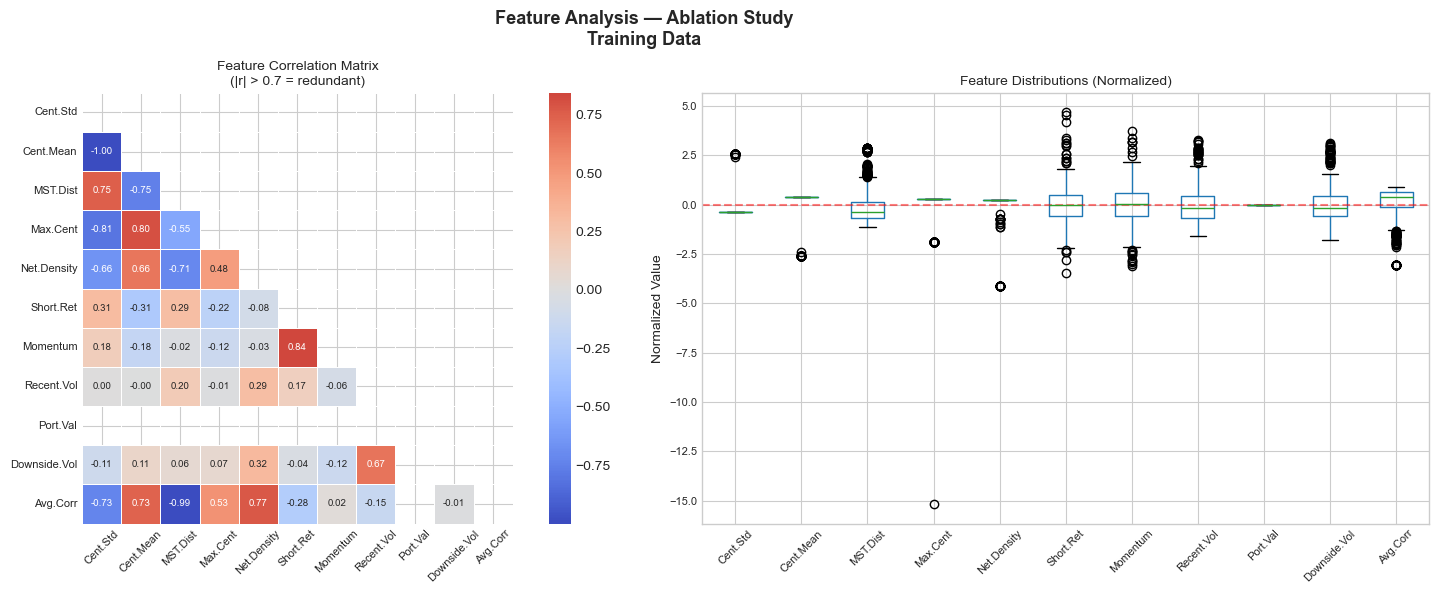


High-correlation pairs (|r| > 0.6):
  Cent.Std <-> Cent.Mean: r = -1.000
  Cent.Std <-> MST.Dist: r = 0.752
  Cent.Std <-> Max.Cent: r = -0.805
  Cent.Std <-> Net.Density: r = -0.657
  Cent.Std <-> Avg.Corr: r = -0.731
  Cent.Mean <-> MST.Dist: r = -0.752
  Cent.Mean <-> Max.Cent: r = 0.805
  Cent.Mean <-> Net.Density: r = 0.657
  Cent.Mean <-> Avg.Corr: r = 0.731
  MST.Dist <-> Net.Density: r = -0.714
  MST.Dist <-> Avg.Corr: r = -0.991
  Net.Density <-> Avg.Corr: r = 0.774
  Short.Ret <-> Momentum: r = 0.843
  Recent.Vol <-> Downside.Vol: r = 0.665


In [31]:
print('=== Phase 4: Global Precompute Cache ===')
print(f'Menghitung cache untuk {len(ret_train) - SET_WINDOW} windows...')

GLOBAL_CACHE = {}

for i in range(SET_WINDOW, len(ret_train)):
    win   = ret_train.iloc[i - SET_WINDOW : i]
    T, N  = win.shape
    mu    = win.mean().values
    sigma = win.std().values
    corr_f    = apply_rmt_filter(win)
    mst, cent_vec = _build_mst_centrality(N, corr_f)
    mst_dist  = sum(d['weight'] for _, _, d in mst.edges(data=True))
    cov_f     = np.outer(sigma, sigma) * corr_f + np.eye(N) * 1e-8
    density   = np.sum(np.abs(corr_f) > 0.1) / (N * N)
    nw_feat_full = np.array([
        np.std(cent_vec)  * 10,
        np.mean(cent_vec) * 10,
        mst_dist          * 0.1,
        np.max(cent_vec),
        density
    ], dtype=np.float32)
    GLOBAL_CACHE[i] = {
        'corr_f'      : corr_f,
        'cent_vec'    : cent_vec,
        'cov_f'       : cov_f,
        'mu'          : mu,
        'sigma'       : sigma,
        'nw_feat_full': nw_feat_full,
    }

print(f'Global cache selesai: {len(GLOBAL_CACHE)} windows cached.')


def build_caches_from_global(config, global_cache):
    obs_cache, opt_cache = {}, {}
    for i, data in global_cache.items():
        nw_feat = data['nw_feat_full'].copy()
        if 'drop_nw_idx' in config:
            nw_feat = np.delete(nw_feat, config['drop_nw_idx'])
        parts = []
        if config['use_network']: parts.append(nw_feat)
        if config['use_market']:  parts.append(np.array([0., 0., 0., 0.], dtype=np.float32))
        if config['extra_features']: parts.append(np.zeros(len(config['extra_features']), dtype=np.float32))
        obs = np.concatenate(parts) if parts else np.array([0.], dtype=np.float32)
        obs_cache[i] = np.nan_to_num(obs)
        opt_cache[i] = (data['cov_f'], data['cent_vec'], data['mu'])
    return obs_cache, opt_cache


print('build_caches_from_global() siap digunakan.')

# Feature Correlation Analysis
feat_names = ['Cent.Std', 'Cent.Mean', 'MST.Dist', 'Max.Cent', 'Net.Density',
              'Short.Ret', 'Momentum', 'Recent.Vol', 'Port.Val', 'Downside.Vol', 'Avg.Corr']

all_features = []
for i in sorted(GLOBAL_CACHE.keys()):
    win = ret_train.iloc[i - SET_WINDOW : i]
    cache = GLOBAL_CACHE[i]
    nw  = cache['nw_feat_full']
    mkt = compute_market_features(win)
    ret_flat = win.values.flatten()
    neg = ret_flat[ret_flat < 0]
    dv = np.std(neg) * np.sqrt(252) * 10 if len(neg) > 0 else 0.0
    upper_tri = cache['corr_f'][np.triu_indices(cache['corr_f'].shape[0], k=1)]
    avg_corr = float(np.mean(np.abs(upper_tri)))
    all_features.append(np.concatenate([nw, mkt, [dv, avg_corr]]))

df_feat = pd.DataFrame(all_features, columns=feat_names)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Feature Analysis — Ablation Study\nTraining Data', fontsize=13, fontweight='bold')

corr_matrix = df_feat.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, ax=axes[0], annot=True, fmt='.2f', cmap='coolwarm',
            center=0, mask=mask, square=True, linewidths=0.5, annot_kws={'size': 7})
axes[0].set_title('Feature Correlation Matrix\n(|r| > 0.7 = redundant)', fontsize=10)
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].tick_params(axis='y', rotation=0, labelsize=8)

df_normalized = (df_feat - df_feat.mean()) / (df_feat.std() + 1e-8)
df_normalized.boxplot(ax=axes[1], rot=45, fontsize=8)
axes[1].set_title('Feature Distributions (Normalized)', fontsize=10)
axes[1].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[1].set_ylabel('Normalized Value')

plt.tight_layout()
plt.savefig('ablation_results_thesis/feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nHigh-correlation pairs (|r| > 0.6):')
found = False
for i in range(len(feat_names)):
    for j in range(i + 1, len(feat_names)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.6:
            print(f'  {feat_names[i]} <-> {feat_names[j]}: r = {r:.3f}')
            found = True
if not found:
    print('  (Tidak ada pasangan dengan |r| > 0.6)')


## Phase 5: Ablation Environment

Reward menggunakan Calmar Ratio berbasis rolling window.

In [32]:
class AblationPortfolioEnv(gym.Env):
    def __init__(self, returns_data, obs_cache, opt_cache,
                 config, window_size=30, gamma_center=1.0):
        super().__init__()
        self.data            = returns_data
        self.obs_cache       = obs_cache
        self.opt_cache       = opt_cache
        self.config          = config
        self.window_size     = window_size
        self.gamma_center    = gamma_center
        self.current_step    = window_size
        self.port_val        = 1.0
        self.peak_val        = 1.0
        self._returns_buffer = []
        self._reward_window  = REWARD_WINDOW
        self._rew_mean  = 0.0
        self._rew_M2    = 0.0
        self._rew_count = 0

        obs_dim = get_obs_dim(config)
        self.action_space      = spaces.Box(low=-5.0, high=5.0, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf,
                                            shape=(obs_dim,), dtype=np.float32)

    def _get_obs(self):
        obs = self.obs_cache[self.current_step].copy()
        if self.config['use_market']:
            offset = 5 if self.config['use_network'] else 0
            port_val_idx = offset + 3
            if port_val_idx < len(obs):
                obs[port_val_idx] = self.port_val - 1.0
        return obs

    def _normalize_reward(self, r):
        self._rew_count += 1
        delta = r - self._rew_mean
        self._rew_mean += delta / self._rew_count
        delta2 = r - self._rew_mean
        self._rew_M2 += delta * delta2
        var = self._rew_M2 / self._rew_count if self._rew_count > 1 else 1.0
        std = max(np.sqrt(var), 1e-6)
        return float(np.clip(r / std, -10.0, 10.0))

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step    = self.window_size
        self.port_val        = 1.0
        self.peak_val        = 1.0
        self._returns_buffer = []
        self._rew_mean       = 0.0
        self._rew_M2         = 0.0
        self._rew_count      = 0
        return self._get_obs(), {}

    def step(self, action):
        gamma = float(np.clip(action[0], -5.0, 5.0)) + self.gamma_center
        cov_f, cent_vec, mu = self.opt_cache[self.current_step]
        w        = fast_centrality_weights(cov_f, cent_vec, mu, gamma)
        port_ret = np.dot(w, self.data.iloc[self.current_step].values)

        self.port_val *= (1 + port_ret)
        self.peak_val  = max(self.peak_val, self.port_val)

        self._returns_buffer.append(port_ret)
        if len(self._returns_buffer) > self._reward_window:
            self._returns_buffer.pop(0)

        arr = np.array(self._returns_buffer)
        if len(arr) < 2:
            raw_reward = port_ret * 100
        else:
            drawdown, _ = _compute_drawdown(arr)
            max_dd      = drawdown.min()
            ann_ret     = calculate_annualized_return(arr)
            if np.isnan(ann_ret):
                ann_ret = arr.mean() * 252
            denominator = abs(max_dd) if abs(max_dd) > 1e-8 else 1e-8
            calmar      = ann_ret / denominator
            raw_reward  = float(np.clip(calmar, -10.0, 10.0))

        reward = self._normalize_reward(raw_reward)
        self.current_step += 1
        done = self.current_step >= len(self.data) - 1
        obs  = self._get_obs() if not done else np.zeros(self.observation_space.shape)
        return obs, reward, done, False, {}


print('AblationPortfolioEnv defined.')


AblationPortfolioEnv defined.


## Phase 6: Learning Curve Callback (FIX 5)

Monitoring reward SAC per episode untuk verifikasi bahwa agen benar-benar belajar.

In [33]:
# FIX 5: Learning curve callback — verifikasi SAC konvergen
class LearningCurveCallback(BaseCallback):
    """
    Rekam episode reward selama training untuk visualisasi learning curve.
    Digunakan untuk membuktikan bahwa TRAIN_STEPS cukup untuk konvergen.
    """
    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.episode_rewards = []
        self._current_ep_reward = 0.0

    def _on_step(self):
        reward = self.locals.get('rewards', [0])[0]
        done   = self.locals.get('dones', [False])[0]
        self._current_ep_reward += reward
        if done:
            self.episode_rewards.append(self._current_ep_reward)
            self._current_ep_reward = 0.0
        return True

    def get_smoothed(self, window=20):
        r = np.array(self.episode_rewards)
        if len(r) < window:
            return r
        return np.convolve(r, np.ones(window)/window, mode='valid')


# Storage untuk learning curves semua seed & config
learning_curves = {}  # key: (exp_id, seed) → LearningCurveCallback

print('LearningCurveCallback defined.')
print('Learning curves akan disimpan di learning_curves[(exp_id, seed)]')


LearningCurveCallback defined.
Learning curves akan disimpan di learning_curves[(exp_id, seed)]


## Phase 7: Backtest Engine & Strategy Classes

In [34]:
class AblationStrategy:
    def __init__(self, name, model_path, config, gamma_center=1.0, global_cache=None):
        self.name         = name
        self.config       = config
        self.gamma_center = gamma_center
        self.global_cache = global_cache
        self.is_static    = config.get('static_gamma') is not None
        if self.is_static:
            self.model      = None
            self.last_gamma = config['static_gamma']
        else:
            self.model      = SAC.load(model_path)
            self.last_gamma = gamma_center

    def compute_weights(self, returns_window, port_val=1.0, step_idx=None):
        if self.is_static:
            self.last_gamma = self.config['static_gamma']
        else:
            obs, _, _ = build_observation(returns_window, self.config, port_val=port_val - 1.0)
            action, _ = self.model.predict(obs, deterministic=True)
            self.last_gamma = float(np.clip(action[0], -5.0, 5.0)) + self.gamma_center

        if self.global_cache is not None and step_idx is not None and step_idx in self.global_cache:
            c = self.global_cache[step_idx]
            return fast_centrality_weights(c['cov_f'], c['cent_vec'], c['mu'], self.last_gamma)
        return get_centrality_weights(returns_window, gamma=self.last_gamma)


def run_backtest(strategy, data, window=30, rebalance_freq=7, data_start_offset=0):
    rets, dates, gamma_history = [], [], []
    current_weights = None
    port_val        = 1.0
    for i in range(window, len(data)):
        if (i - window) % rebalance_freq == 0:
            window_df  = data.iloc[i - window : i]
            global_idx = data_start_offset + i
            current_weights = strategy.compute_weights(
                window_df,
                port_val=(1.0 if strategy.is_static else port_val),
                step_idx=global_idx
            )
        if current_weights is not None:
            daily_ret = np.dot(current_weights, data.iloc[i].values)
            port_val  = port_val * (1 + daily_ret)
            rets.append(daily_ret)
            dates.append(data.index[i])
            gamma_history.append(getattr(strategy, 'last_gamma', 1.0))
    return (pd.Series(rets, index=dates, name=strategy.name),
            pd.Series(gamma_history, index=dates))


def run_backtest_baselines(data, assets, window=30):
    """
    Simulasi strategi benchmark: Classic-MV.

    FIX 8 & 9: Classic-MV kini menggunakan compute_classic_mv_weights()
    yang terpisah — sample covariance murni (np.cov), tanpa RMT filter,
    tanpa pengaruh centrality, bounds (0, 1.0). Ini merepresentasikan
    Markowitz (1952) klasik yang sebenarnya sebagai baseline yang bersih.
    """
    n_assets = len(assets)
    dates = data.index[window:]

    # Classic Markowitz (Classic-MV) — FIX: fungsi terpisah, sample cov murni
    cmv_rets = []
    w_mv = np.ones(n_assets) / n_assets
    for i in range(window, len(data)):
        if (i - window) % 7 == 0:
            win  = data.iloc[i - window : i]
            w_mv = compute_classic_mv_weights(win)  # FIX: dedicated function
        cmv_rets.append(np.dot(w_mv, data.iloc[i].values))

    return {
        'Classic-MV': pd.Series(cmv_rets, index=dates),
    }


print('Backtest engine + ERC baseline defined.')


Backtest engine + ERC baseline defined.


## Phase 8: Training — Multi-Seed (FIX 1 & 2)

`SEEDS = [42, 123, 77]` dan `TRAIN_STEPS = 10000`. Learning curve direkam per seed.

In [35]:
# FIX 1 & 2: Multi-seed training dengan TRAIN_STEPS=10000
sac_kwargs = {
    'policy'         : 'MlpPolicy',
    'learning_rate'  : 3e-4,
    'buffer_size'    : 50000,
    'batch_size'     : 256,
    'ent_coef'       : 'auto',
    'train_freq'     : 1,
    'gradient_steps' : 1,
    'learning_starts': 200,   # < TRAIN_STEPS=10000, aman
    'tau'            : 0.005,
    'gamma'          : 0.99,
}

trained_model_paths = {}

sep = '=' * 60
for exp_id, config in ABLATION_CONFIGS.items():
    print(f'\n{sep}')
    print(f'Experiment: {exp_id} | obs_dim={get_obs_dim(config)}')

    obs_cache, opt_cache = build_caches_from_global(config, GLOBAL_CACHE)

    for seed in SEEDS:
        if config.get('static_gamma') is not None:
            if seed == SEEDS[0]:
                print(f'  Static benchmark {exp_id} — tidak perlu training.')
            trained_model_paths[(exp_id, seed)] = 'static'
            continue

        print(f'  Training seed={seed} | TRAIN_STEPS={TRAIN_STEPS}...')
        env = AblationPortfolioEnv(
            ret_train, obs_cache, opt_cache, config,
            window_size=SET_WINDOW, gamma_center=GAMMA_CENTER,
        )

        # FIX 5: Attach learning curve callback
        lc_callback = LearningCurveCallback()
        model = SAC(env=env, seed=seed, verbose=0, **sac_kwargs)
        model.learn(total_timesteps=TRAIN_STEPS, callback=lc_callback, progress_bar=True)

        learning_curves[(exp_id, seed)] = lc_callback
        model_name = f'ablation_{exp_id}_seed{seed}'
        model.save(model_name)
        trained_model_paths[(exp_id, seed)] = model_name
        print(f'    Saved: {model_name}.zip | Episodes recorded: {len(lc_callback.episode_rewards)}')

print('\n=== Semua model ablation selesai dilatih ===')


Output()


Experiment: Comp_Static_Gamma0 | obs_dim=5
  Static benchmark Comp_Static_Gamma0 — tidak perlu training.

Experiment: Comp_Static_Gamma1 | obs_dim=5
  Static benchmark Comp_Static_Gamma1 — tidak perlu training.

Experiment: Comp_Static_Gamma2 | obs_dim=5
  Static benchmark Comp_Static_Gamma2 — tidak perlu training.

Experiment: E2_NoMarket | obs_dim=5
  Training seed=42 | TRAIN_STEPS=25000...


Output()

    Saved: ablation_E2_NoMarket_seed42.zip | Episodes recorded: 49
  Training seed=123 | TRAIN_STEPS=25000...


Output()

    Saved: ablation_E2_NoMarket_seed123.zip | Episodes recorded: 49
  Training seed=77 | TRAIN_STEPS=25000...


    Saved: ablation_E2_NoMarket_seed77.zip | Episodes recorded: 49

=== Semua model ablation selesai dilatih ===


## Phase 8B: Visualisasi Learning Curves (FIX 5)

Verifikasi bahwa SAC benar-benar belajar (reward meningkat seiring training).

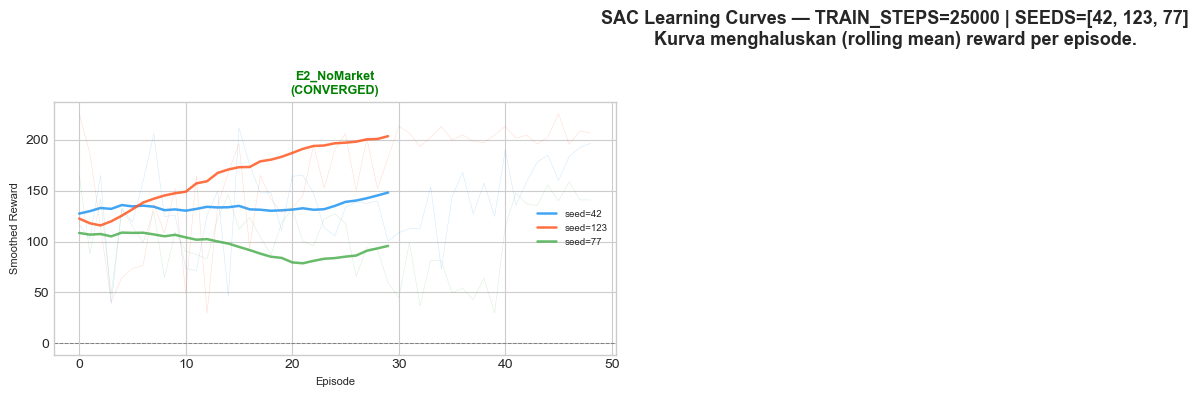

Saved: ablation_results_thesis/learning_curves.png


In [36]:
# FIX 5: Plot learning curves untuk semua SAC configs
sac_configs = [k for k, v in ABLATION_CONFIGS.items() if v.get('static_gamma') is None]
n_configs = len(sac_configs)
ncols = 3
nrows = (n_configs + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
fig.suptitle(f'SAC Learning Curves — TRAIN_STEPS={TRAIN_STEPS} | SEEDS={SEEDS}\n'
             'Kurva menghaluskan (rolling mean) reward per episode.',
             fontsize=13, fontweight='bold')

axes_flat = axes.flatten() if nrows > 1 else [axes] if ncols == 1 else axes.flatten()

seed_colors = {42: '#2196F3', 123: '#FF5722', 77: '#4CAF50'}

for ax, exp_id in zip(axes_flat, sac_configs):
    converged_count = 0
    for seed in SEEDS:
        key = (exp_id, seed)
        if key not in learning_curves:
            continue
        lc = learning_curves[key]
        raw = np.array(lc.episode_rewards)
        if len(raw) == 0:
            continue
        smoothed = lc.get_smoothed(window=20)
        x_smooth = np.arange(len(smoothed))
        ax.plot(x_smooth, smoothed, color=seed_colors[seed],
                linewidth=1.8, label=f'seed={seed}', alpha=0.85)
        ax.plot(np.arange(len(raw)), raw, color=seed_colors[seed],
                linewidth=0.4, alpha=0.2)
        # Tandai konvergensi: reward akhir > reward awal
        if len(smoothed) > 10 and smoothed[-1] > smoothed[0]:
            converged_count += 1

    ax.set_title(f'{exp_id}\n({"CONVERGED" if converged_count >= len(SEEDS)//2+1 else "CHECK"})',
                 fontsize=9, fontweight='bold',
                 color='green' if converged_count >= len(SEEDS)//2+1 else 'red')
    ax.set_xlabel('Episode', fontsize=8)
    ax.set_ylabel('Smoothed Reward', fontsize=8)
    ax.legend(fontsize=7)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.7)

# Hide unused axes
for ax in axes_flat[len(sac_configs):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig('ablation_results_thesis/learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ablation_results_thesis/learning_curves.png')


## Phase 9: Backtest — Training & Testing Data

In [37]:
ablation_results = {}

for exp_id, config in ABLATION_CONFIGS.items():
    print(f'\nBacktest: {exp_id}')
    ablation_results[exp_id] = {'train': {}, 'test': {}}

    for seed in SEEDS:
        model_path = trained_model_paths[(exp_id, seed)]
        strat = AblationStrategy(
            f'{exp_id}_s{seed}', model_path, config, GAMMA_CENTER,
            global_cache=GLOBAL_CACHE
        )

        ret_tr, _ = run_backtest(strat, ret_train, SET_WINDOW, SET_REBALANCE,
                                  data_start_offset=0)
        ablation_results[exp_id]['train'][seed] = ret_tr

        ret_te, _ = run_backtest(strat, ret_test, SET_WINDOW, SET_REBALANCE,
                                  data_start_offset=len(ret_train))
        ablation_results[exp_id]['test'][seed] = ret_te

        m_tr = calculate_all_metrics(ret_tr, CVAR_LEVEL)
        m_te = calculate_all_metrics(ret_te, CVAR_LEVEL)
        print(f'  [TRAIN] seed={seed} | Sharpe={m_tr["Sharpe Ratio"]:.3f} | '
              f'Sortino={m_tr["Sortino Ratio"]:.3f} | Calmar={m_tr["Calmar Ratio"]:.3f} | '
              f'CVaR={m_tr["CVaR (95%)"]:.4f}')
        print(f'  [TEST ] seed={seed} | Sharpe={m_te["Sharpe Ratio"]:.3f} | '
              f'Sortino={m_te["Sortino Ratio"]:.3f} | Calmar={m_te["Calmar Ratio"]:.3f} | '
              f'CVaR={m_te["CVaR (95%)"]:.4f}')

print('Running Baselines (Classic-MV only)...')
baselines_train = run_backtest_baselines(ret_train, assets, SET_WINDOW)
baselines_test  = run_backtest_baselines(ret_test,  assets, SET_WINDOW)

for b_name in ['Classic-MV']:
    ablation_results[b_name] = {'train': {}, 'test': {}}
    for seed in SEEDS:
        ablation_results[b_name]['train'][seed] = baselines_train[b_name]
        ablation_results[b_name]['test'][seed]  = baselines_test[b_name]

    m_tr = calculate_all_metrics(baselines_train[b_name], CVAR_LEVEL)
    m_te = calculate_all_metrics(baselines_test[b_name], CVAR_LEVEL)
    print(f'  [BASELINE: {b_name}]')
    print(f'    TRAIN: Sharpe={m_tr["Sharpe Ratio"]:.3f} | Calmar={m_tr["Calmar Ratio"]:.3f}')
    print(f'    TEST : Sharpe={m_te["Sharpe Ratio"]:.3f} | Calmar={m_te["Calmar Ratio"]:.3f}')

print('\nSemua backtest selesai.')



Backtest: Comp_Static_Gamma0
  [TRAIN] seed=42 | Sharpe=-0.417 | Sortino=-0.547 | Calmar=-0.344 | CVaR=0.1159
  [TEST ] seed=42 | Sharpe=-0.075 | Sortino=-0.095 | Calmar=-0.085 | CVaR=0.0985
  [TRAIN] seed=123 | Sharpe=-0.417 | Sortino=-0.547 | Calmar=-0.344 | CVaR=0.1159
  [TEST ] seed=123 | Sharpe=-0.075 | Sortino=-0.095 | Calmar=-0.085 | CVaR=0.0985
  [TRAIN] seed=77 | Sharpe=-0.417 | Sortino=-0.547 | Calmar=-0.344 | CVaR=0.1159
  [TEST ] seed=77 | Sharpe=-0.075 | Sortino=-0.095 | Calmar=-0.085 | CVaR=0.0985

Backtest: Comp_Static_Gamma1
  [TRAIN] seed=42 | Sharpe=-0.663 | Sortino=-0.932 | Calmar=-0.620 | CVaR=0.1250
  [TEST ] seed=42 | Sharpe=-0.104 | Sortino=-0.135 | Calmar=-0.118 | CVaR=0.0976
  [TRAIN] seed=123 | Sharpe=-0.663 | Sortino=-0.932 | Calmar=-0.620 | CVaR=0.1250
  [TEST ] seed=123 | Sharpe=-0.104 | Sortino=-0.135 | Calmar=-0.118 | CVaR=0.0976
  [TRAIN] seed=77 | Sharpe=-0.663 | Sortino=-0.932 | Calmar=-0.620 | CVaR=0.1250
  [TEST ] seed=77 | Sharpe=-0.104 | Sortino=-

## Phase 10: Agregasi Hasil — 4 Metrik Utama Tesis

In [38]:
def _agg(metrics_list, key):
    vals = [m[key] for m in metrics_list]
    return np.nanmean(vals), np.nanstd(vals)


summary_rows = []
ALL_IDS = list(ABLATION_CONFIGS.keys()) + ['Classic-MV']

for exp_id in ALL_IDS:
    config = ABLATION_CONFIGS.get(exp_id, {})
    train_metrics = [calculate_all_metrics(ablation_results[exp_id]['train'][s], CVAR_LEVEL) for s in SEEDS]
    test_metrics  = [calculate_all_metrics(ablation_results[exp_id]['test'][s],  CVAR_LEVEL) for s in SEEDS]

    if exp_id in ['Classic-MV']:
        feature_desc = ['Standard Baseline']
    elif config.get('static_gamma') is not None:
        feature_desc = [f'Static Gamma {config["static_gamma"]}']
    else:
        feature_desc  = (['Network(5)'] if config['use_network'] else [])
        feature_desc += (['Market(4)']  if config['use_market']  else [])
        feature_desc += config['extra_features']

    row = {
        'Experiment': exp_id,
        'Features'  : ' + '.join(feature_desc),
        'Obs Dim'   : get_obs_dim(config) if exp_id in ABLATION_CONFIGS else 0,
    }

    for period, metrics_list in [('Train', train_metrics), ('Test', test_metrics)]:
        for metric in FOUR_METRICS:
            mean, std = _agg(metrics_list, metric)
            col_key = METRIC_KEY[metric]
            row[f'{col_key}_{period}_Mean'] = mean
            row[f'{col_key}_{period}_Std']  = std

    tr_ann_m, _ = _agg(train_metrics, 'Ann. Return')
    te_ann_m, _ = _agg(test_metrics,  'Ann. Return')
    tr_tot_m, _ = _agg(train_metrics, 'Total Return')
    te_tot_m, _ = _agg(test_metrics,  'Total Return')
    row['AnnRet_Train_Mean'] = tr_ann_m
    row['AnnRet_Test_Mean']  = te_ann_m
    row['TotalRet_Gap']      = tr_tot_m - te_tot_m

    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index('Experiment')
summary_df.to_csv('ablation_results_thesis/ablation_summary_4metrics.csv')

sep = '=' * 90
print(sep)
print('ABLATION STUDY — 4 METRIK UTAMA TESIS (Testing Period)')
print(sep)
print(f'{"Experiment":<25} {"Sharpe":>10} {"Sortino":>10} {"Calmar":>10} {"CVaR(95%)":>12}')
print('-' * 70)
for exp_id, row in summary_df.iterrows():
    print(f'{exp_id:<25} '
          f'{row["SharpeRatio_Test_Mean"]:>10.4f} '
          f'{row["SortinoRatio_Test_Mean"]:>10.4f} '
          f'{row["CalmarRatio_Test_Mean"]:>10.4f} '
          f'{row["CVaR95pct_Test_Mean"]:>12.5f}')
print(sep)


ABLATION STUDY — 4 METRIK UTAMA TESIS (Testing Period)
Experiment                    Sharpe    Sortino     Calmar    CVaR(95%)
----------------------------------------------------------------------
Comp_Static_Gamma0           -0.0752    -0.0947    -0.0846      0.09853
Comp_Static_Gamma1           -0.1039    -0.1349    -0.1178      0.09764
Comp_Static_Gamma2           -0.1039    -0.1349    -0.1178      0.09764
E2_NoMarket                   0.2746     0.3255     0.3750      0.12472
Classic-MV                   -0.1054    -0.1335    -0.1188      0.09784


## Phase 11: Uji Signifikansi Statistik (FIX 3)

Wilcoxon signed-rank test untuk membuktikan perbedaan performa signifikan secara statistik, bukan hanya kebetulan.

In [39]:
# FIX 3: Uji signifikansi statistik — Wilcoxon signed-rank test
# Membandingkan distribusi daily returns antar konfigurasi

print('=' * 70)
print('UJI SIGNIFIKANSI STATISTIK — Wilcoxon Signed-Rank Test')
print(f'Alpha = {STAT_ALPHA} | Menggunakan data: Testing Period')
print('=' * 70)

# Proposed method vs semua baseline & static gamma
proposed_id = 'E2_NoMarket'
comparison_ids = ['Comp_Static_Gamma0', 'Comp_Static_Gamma1', 'Comp_Static_Gamma2',
                  'Classic-MV']

# Gabungkan returns dari semua seed (pooled)
def get_pooled_returns(exp_id, period='test'):
    """Gabungkan daily returns dari semua seed untuk satu experiment."""
    all_rets = []
    for seed in SEEDS:
        r = ablation_results[exp_id][period][seed]
        all_rets.append(r.values)
    # Ambil panjang minimum agar bisa dibandingkan
    min_len = min(len(r) for r in all_rets)
    return np.concatenate([r[:min_len] for r in all_rets])


stat_results = []

proposed_rets = get_pooled_returns(proposed_id)

print(f'\nMembandingkan {proposed_id} vs Baseline (Test Period, pooled {len(SEEDS)} seeds):')
print(f'{"Comparison":<25} {"Stat":>10} {"p-value":>12} {"Significant":>12} {"Conclusion":>30}')
print('-' * 90)

for comp_id in comparison_ids:
    comp_rets = get_pooled_returns(comp_id)
    min_len   = min(len(proposed_rets), len(comp_rets))
    d1 = proposed_rets[:min_len]
    d2 = comp_rets[:min_len]

    try:
        stat, pval = stats.wilcoxon(d1, d2, alternative='two-sided')
        is_sig = pval < STAT_ALPHA
        proposed_mean = np.mean(d1)
        comp_mean     = np.mean(d2)
        direction = 'PROPOSED LEBIH BAIK' if proposed_mean > comp_mean else 'PROPOSED LEBIH BURUK'
        conclusion = f'{direction} (p={pval:.4f})' if is_sig else f'TIDAK BERBEDA SIGNIFIKAN'
    except Exception as e:
        stat, pval, is_sig, conclusion = np.nan, np.nan, False, f'ERROR: {e}'

    print(f'{comp_id:<25} {stat:>10.3f} {pval:>12.4f} {"YA ✓" if is_sig else "TIDAK ✗":>12} {conclusion:>30}')
    stat_results.append({
        'Proposed'   : proposed_id,
        'Compared_to': comp_id,
        'Statistic'  : stat,
        'p_value'    : pval,
        'Significant': is_sig,
        'Conclusion' : conclusion,
    })

print()
print('Ablation: E2_NoMarket vs Drop-Feature configs (Sharpe Ratio per-seed, uji berpasangan):')
print(f'{"Comparison":<25} {"Sharpe Proposed":>16} {"Sharpe Compared":>16} {"p-value":>10} {"Significant":>12}')
print('-' * 85)

proposed_sharpes = [
    calculate_sharpe_ratio(ablation_results[proposed_id]['test'][s])
    for s in SEEDS
]
for comp_id in LOO_EXPS[1:]:  # skip E2_NoMarket itself
    comp_sharpes = [
        calculate_sharpe_ratio(ablation_results[comp_id]['test'][s])
        for s in SEEDS
    ]
    if len(SEEDS) >= 3:
        try:
            stat, pval = stats.wilcoxon(proposed_sharpes, comp_sharpes)
            is_sig = pval < STAT_ALPHA
        except Exception:
            pval, is_sig = np.nan, False
    else:
        pval, is_sig = np.nan, False
        print(f'  (Perlu ≥3 seed untuk Wilcoxon berpasangan — gunakan multi-seed)')

    print(f'{comp_id:<25} {np.mean(proposed_sharpes):>16.4f} {np.mean(comp_sharpes):>16.4f} '
          f'{pval:>10.4f} {"YA ✓" if is_sig else "TIDAK ✗":>12}')
    stat_results.append({
        'Proposed'   : proposed_id,
        'Compared_to': comp_id,
        'Statistic'  : np.nan,
        'p_value'    : pval,
        'Significant': is_sig,
        'Conclusion' : 'Sharpe pair test',
    })

stat_df = pd.DataFrame(stat_results)
stat_df.to_csv('ablation_results_thesis/statistical_tests.csv', index=False)
print('\nSaved: ablation_results_thesis/statistical_tests.csv')


UJI SIGNIFIKANSI STATISTIK — Wilcoxon Signed-Rank Test
Alpha = 0.05 | Menggunakan data: Testing Period

Membandingkan E2_NoMarket vs Baseline (Test Period, pooled 3 seeds):
Comparison                      Stat      p-value  Significant                     Conclusion
------------------------------------------------------------------------------------------
Comp_Static_Gamma0         81486.000       0.0655      TIDAK ✗       TIDAK BERBEDA SIGNIFIKAN
Comp_Static_Gamma1         80994.000       0.0502      TIDAK ✗       TIDAK BERBEDA SIGNIFIKAN
Comp_Static_Gamma2         80994.000       0.0502      TIDAK ✗       TIDAK BERBEDA SIGNIFIKAN
Classic-MV                 81372.000       0.0616      TIDAK ✗       TIDAK BERBEDA SIGNIFIKAN

Ablation: E2_NoMarket vs Drop-Feature configs (Sharpe Ratio per-seed, uji berpasangan):
Comparison                 Sharpe Proposed  Sharpe Compared    p-value  Significant
-------------------------------------------------------------------------------------

Saved:

## Phase 12: Walk-Forward Robustness Check (FIX 6)

Membagi test set menjadi 3 sub-periode untuk menguji konsistensi performa.

=== Walk-Forward Robustness Check ===
Test set dibagi menjadi 3 sub-periode.

Period-1 (Early): 2019-03-03 – 2019-05-17 (76 days)
Period-2 (Mid): 2019-05-18 – 2019-08-01 (76 days)
Period-3 (Late): 2019-08-02 – 2019-10-17 (77 days)


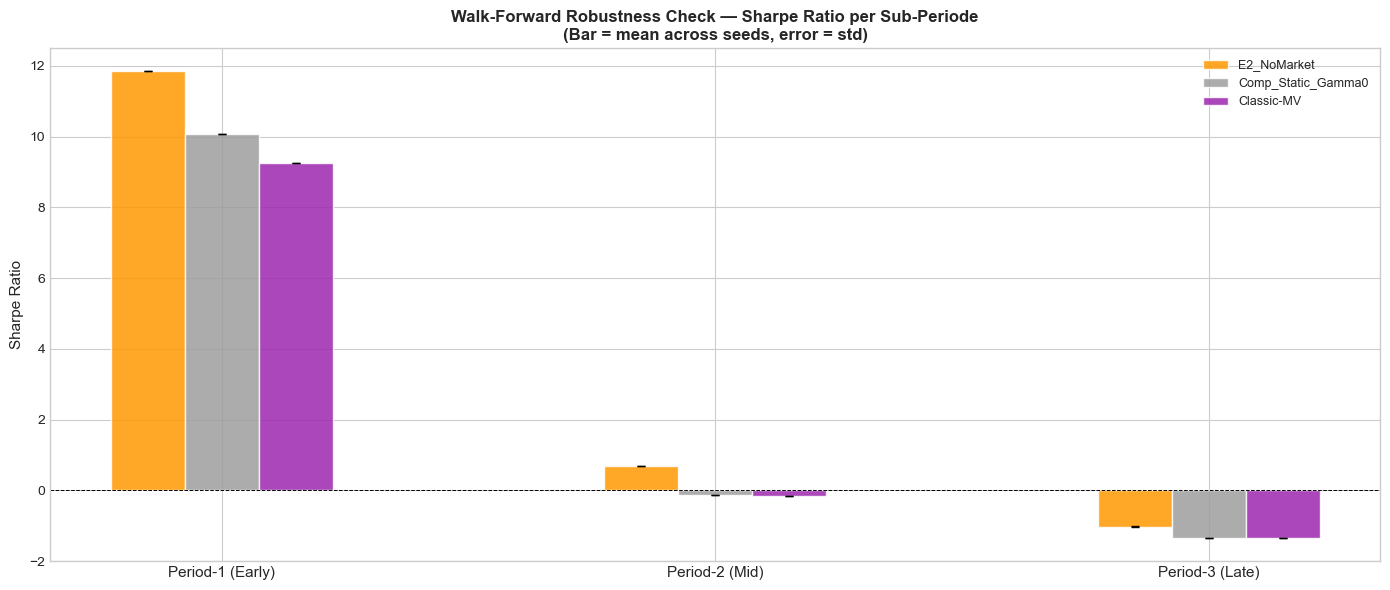


Saved: ablation_results_thesis/walkforward_robustness.png
Saved: ablation_results_thesis/walkforward_results.csv

Konsistensi E2_NoMarket vs EW per sub-periode:
  Period-1 (Early): E2=11.8492 | Classic-MV=9.2685 | Δ=+2.5808 ✓
  Period-2 (Mid): E2=0.6872 | Classic-MV=-0.1490 | Δ=+0.8363 ✓
  Period-3 (Late): E2=-1.0286 | Classic-MV=-1.3414 | Δ=+0.3128 ✓


In [40]:
# FIX 6: Walk-forward robustness check
# Bagi test set menjadi 3 sub-windows dan evaluasi setiap periode
print('=== Walk-Forward Robustness Check ===')
print(f'Test set dibagi menjadi 3 sub-periode.')
print()

n_test = len(ret_test)
window_ids = [
    ('Period-1 (Early)',  ret_test.iloc[:n_test//3]),
    ('Period-2 (Mid)',    ret_test.iloc[n_test//3 : 2*n_test//3]),
    ('Period-3 (Late)',   ret_test.iloc[2*n_test//3 :]),
]

# Evaluasi hanya untuk proposed vs 3 baseline utama
wf_ids = ['E2_NoMarket', 'Comp_Static_Gamma0', 'Classic-MV']
wf_metric = 'Sharpe Ratio'

wf_rows = []

for period_label, period_data in window_ids:
    print(f'{period_label}: {period_data.index[0].date()} – {period_data.index[-1].date()} ({len(period_data)} days)')
    for exp_id in wf_ids:
        sharpes = []
        for seed in SEEDS:
            # Kita pakai daily returns dari backtest penuh, ambil irisan periode ini
            full_ret = ablation_results[exp_id]['test'][seed]
            # Irisan berdasarkan tanggal
            mask = (full_ret.index >= period_data.index[0]) & (full_ret.index <= period_data.index[-1])
            period_ret = full_ret[mask]
            if len(period_ret) > 10:
                sharpes.append(calculate_sharpe_ratio(period_ret))
        if sharpes:
            wf_rows.append({
                'Period'    : period_label,
                'Experiment': exp_id,
                'Sharpe_Mean': np.mean(sharpes),
                'Sharpe_Std' : np.std(sharpes),
            })

wf_df = pd.DataFrame(wf_rows)

# Plot walk-forward consistency
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len([p for p, _ in window_ids]))
width = 0.15

for i, exp_id in enumerate(wf_ids):
    exp_data = wf_df[wf_df['Experiment'] == exp_id]
    means = exp_data['Sharpe_Mean'].values
    stds  = exp_data['Sharpe_Std'].values
    offset = (i - len(wf_ids)/2) * width + width/2
    bars = ax.bar(x + offset, means, width, yerr=stds, capsize=3,
                  color=ABLATION_COLORS.get(exp_id, '#888'),
                  label=exp_id, alpha=0.85, edgecolor='white')

ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
ax.set_xticks(x)
ax.set_xticklabels([p for p, _ in window_ids], fontsize=11)
ax.set_ylabel('Sharpe Ratio', fontsize=11)
ax.set_title('Walk-Forward Robustness Check — Sharpe Ratio per Sub-Periode\n'
             '(Bar = mean across seeds, error = std)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('ablation_results_thesis/walkforward_robustness.png', dpi=150, bbox_inches='tight')
plt.show()

wf_df.to_csv('ablation_results_thesis/walkforward_results.csv', index=False)
print('\nSaved: ablation_results_thesis/walkforward_robustness.png')
print('Saved: ablation_results_thesis/walkforward_results.csv')

# Consistency score: apakah proposed selalu outperform EW di setiap periode?
print('\nKonsistensi E2_NoMarket vs EW per sub-periode:')
for period_label, _ in window_ids:
    proposed_sharpe = wf_df[(wf_df['Period']==period_label) & (wf_df['Experiment']=='E2_NoMarket')]['Sharpe_Mean'].values
    cmv_sharpe = wf_df[(wf_df['Period']==period_label) & (wf_df['Experiment']=='Classic-MV')]['Sharpe_Mean'].values
    if len(proposed_sharpe) > 0 and len(cmv_sharpe) > 0:
        delta = proposed_sharpe[0] - cmv_sharpe[0]
        sign = '✓' if delta > 0 else '✗'
        print(f'  {period_label}: E2={proposed_sharpe[0]:.4f} | Classic-MV={cmv_sharpe[0]:.4f} | Δ={delta:+.4f} {sign}')


## Phase 13: Visualisasi — 4 Metrik Utama

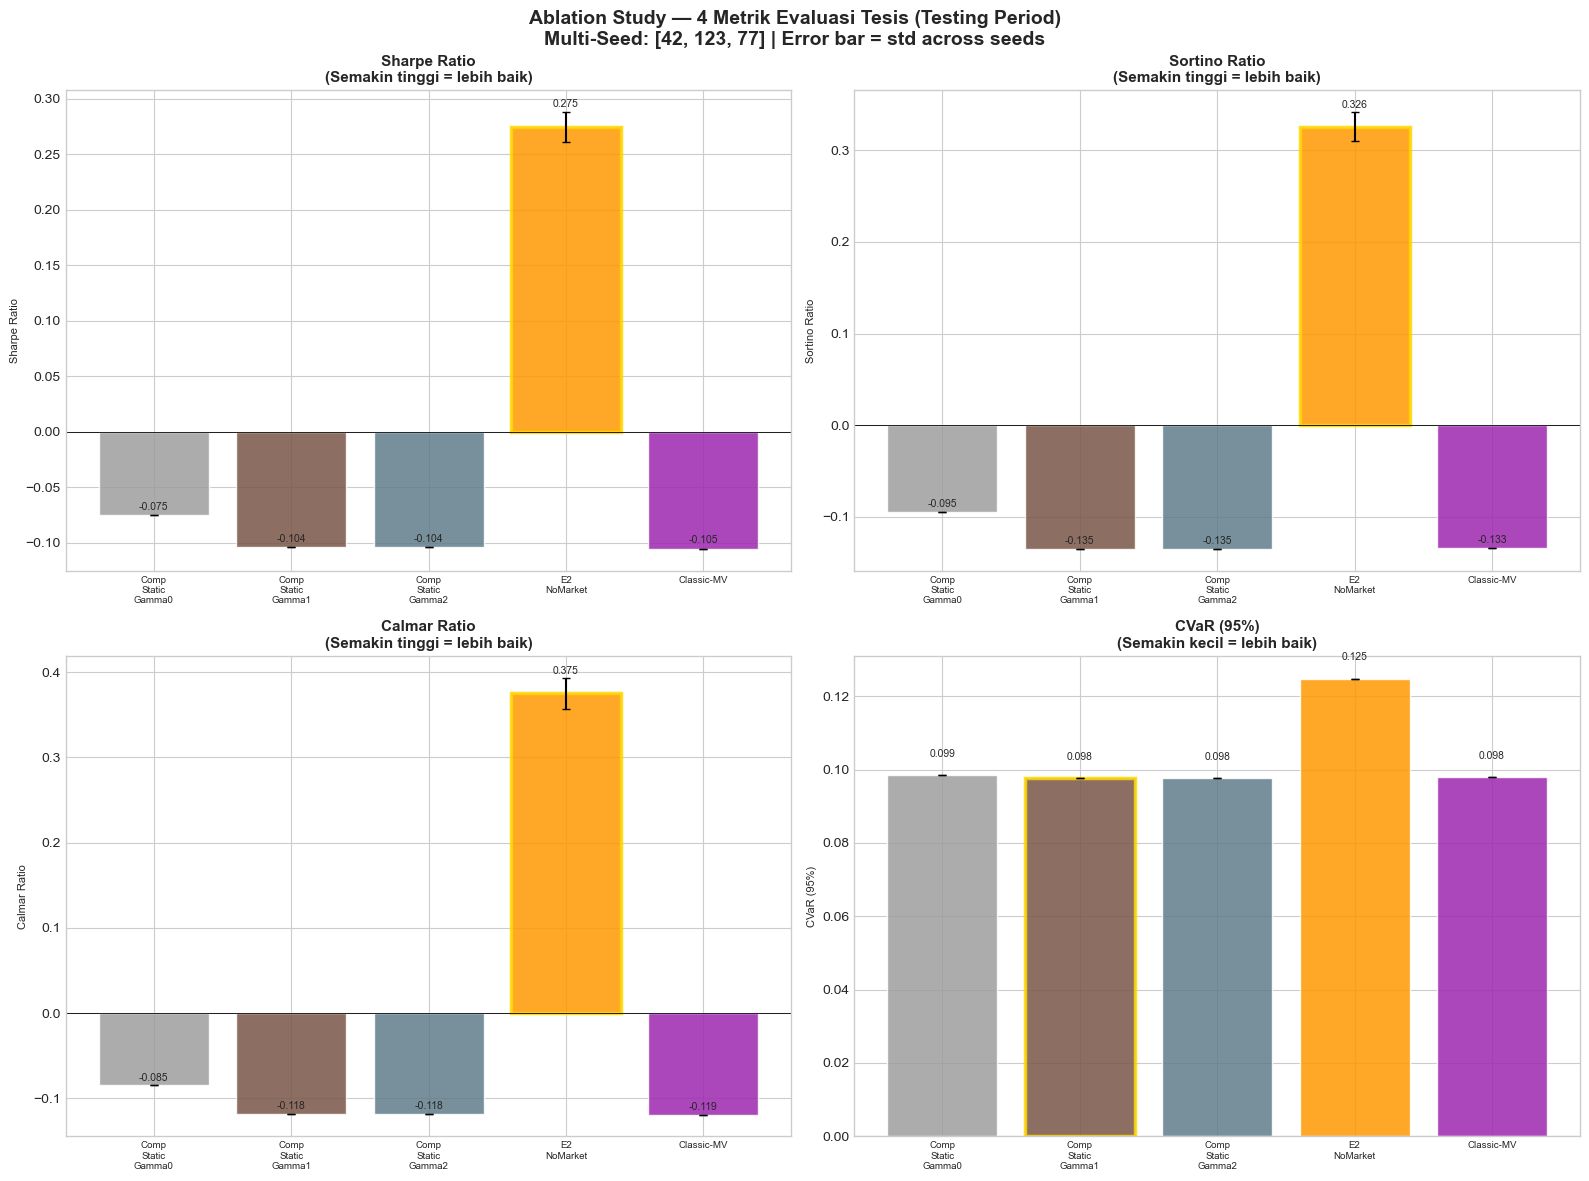

Saved: ablation_results_thesis/4metrics_bar.png


In [41]:
exp_ids = list(summary_df.index)
colors  = [ABLATION_COLORS.get(e, '#888888') for e in exp_ids]

# Vis 1: Bar Chart 4 Metrik (Testing)
metrics_to_plot = [
    ('SharpeRatio_Test_Mean',  'SharpeRatio_Test_Std',  'Sharpe Ratio',  'Semakin tinggi = lebih baik', False),
    ('SortinoRatio_Test_Mean', 'SortinoRatio_Test_Std', 'Sortino Ratio', 'Semakin tinggi = lebih baik', False),
    ('CalmarRatio_Test_Mean',  'CalmarRatio_Test_Std',  'Calmar Ratio',  'Semakin tinggi = lebih baik', False),
    ('CVaR95pct_Test_Mean',    'CVaR95pct_Test_Std',    'CVaR (95%)',    'Semakin kecil = lebih baik',  True),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'Ablation Study — 4 Metrik Evaluasi Tesis (Testing Period)\n'
             f'Multi-Seed: {SEEDS} | Error bar = std across seeds',
             fontsize=14, fontweight='bold')

for ax, (mean_col, std_col, label, note, lower_better) in zip(axes.flatten(), metrics_to_plot):
    bars, vals, errs = _plot_metric_bars(
        ax, summary_df, exp_ids, colors, mean_col, std_col, label, lower_better,
        short_labels=False
    )
    ax.set_title(f'{label}\n({note})', fontsize=11, fontweight='bold')
    ax.set_xticklabels([e.replace('_', '\n') for e in exp_ids], fontsize=7)
    for bar, v, e in zip(bars, vals, errs):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (e if v >= 0 else 0) + 0.005,
                f'{v:.3f}', ha='center', fontsize=7.5)

plt.tight_layout()
plt.savefig('ablation_results_thesis/4metrics_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ablation_results_thesis/4metrics_bar.png')


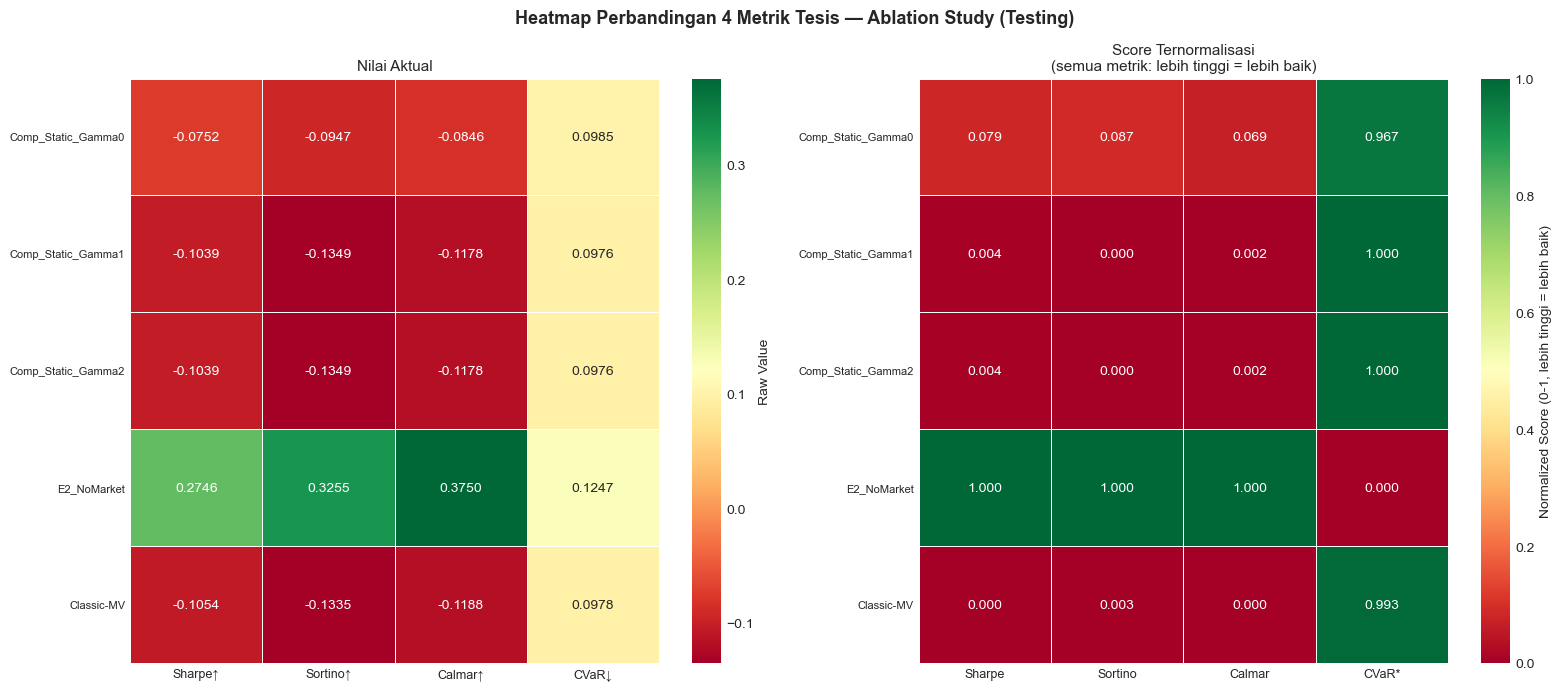

Saved: ablation_results_thesis/4metrics_heatmap.png


In [42]:
# Vis 2: Heatmap 4 Metrik (Testing)
heatmap_data, heatmap_norm = _build_heatmap_data(summary_df, exp_ids, 'Test')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Heatmap Perbandingan 4 Metrik Tesis — Ablation Study (Testing)',
             fontsize=13, fontweight='bold')

sns.heatmap(heatmap_data, ax=axes[0], annot=True, fmt='.4f',
            cmap='RdYlGn', linewidths=0.5, cbar_kws={'label': 'Raw Value'})
axes[0].set_title('Nilai Aktual', fontsize=11)
axes[0].tick_params(axis='y', labelsize=8, rotation=0)
axes[0].set_xticklabels(['Sharpe↑', 'Sortino↑', 'Calmar↑', 'CVaR↓'], fontsize=9)

sns.heatmap(heatmap_norm, ax=axes[1], annot=True, fmt='.3f',
            cmap='RdYlGn', linewidths=0.5, vmin=0, vmax=1,
            cbar_kws={'label': 'Normalized Score (0-1, lebih tinggi = lebih baik)'})
axes[1].set_title('Score Ternormalisasi\n(semua metrik: lebih tinggi = lebih baik)', fontsize=11)
axes[1].tick_params(axis='y', labelsize=8, rotation=0)
axes[1].set_xticklabels(['Sharpe', 'Sortino', 'Calmar', 'CVaR*'], fontsize=9)

plt.tight_layout()
plt.savefig('ablation_results_thesis/4metrics_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ablation_results_thesis/4metrics_heatmap.png')


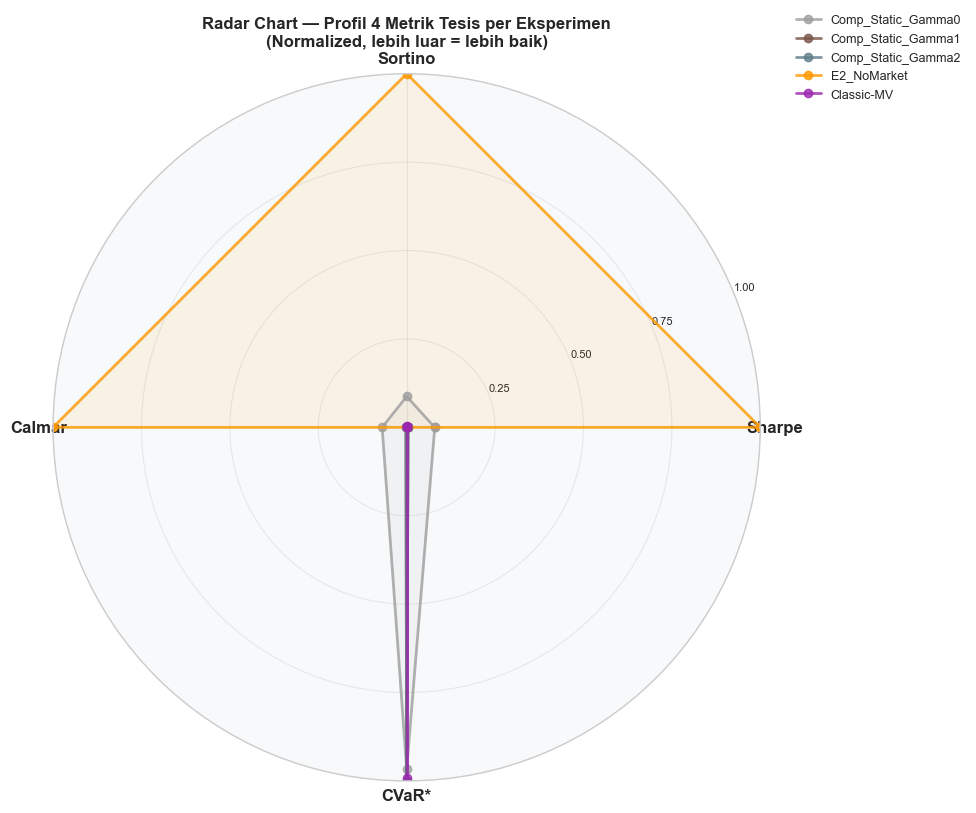

Saved: ablation_results_thesis/4metrics_radar.png


In [43]:
# Vis 3: Radar Chart — Profil Risiko (main exps saja)
radar_metrics = ['Sharpe', 'Sortino', 'Calmar', 'CVaR*']
N_metrics = len(radar_metrics)
angles = np.linspace(0, 2 * np.pi, N_metrics, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
ax.set_facecolor('#F8F9FA')

plot_main_exps = [e for e in MAIN_EXPS if e in heatmap_norm.index]
for exp_id in plot_main_exps:
    values = heatmap_norm.loc[exp_id, ['Sharpe', 'Sortino', 'Calmar', 'CVaR(95%)']].values.tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2,
            color=ABLATION_COLORS.get(exp_id, '#888'), label=exp_id, alpha=0.8)
    ax.fill(angles, values, alpha=0.08, color=ABLATION_COLORS.get(exp_id, '#888'))

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_metrics, fontsize=12, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0.25', '0.50', '0.75', '1.00'], fontsize=8)
ax.set_title('Radar Chart — Profil 4 Metrik Tesis per Eksperimen\n'
             '(Normalized, lebih luar = lebih baik)',
             fontsize=12, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9)
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('ablation_results_thesis/4metrics_radar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ablation_results_thesis/4metrics_radar.png')


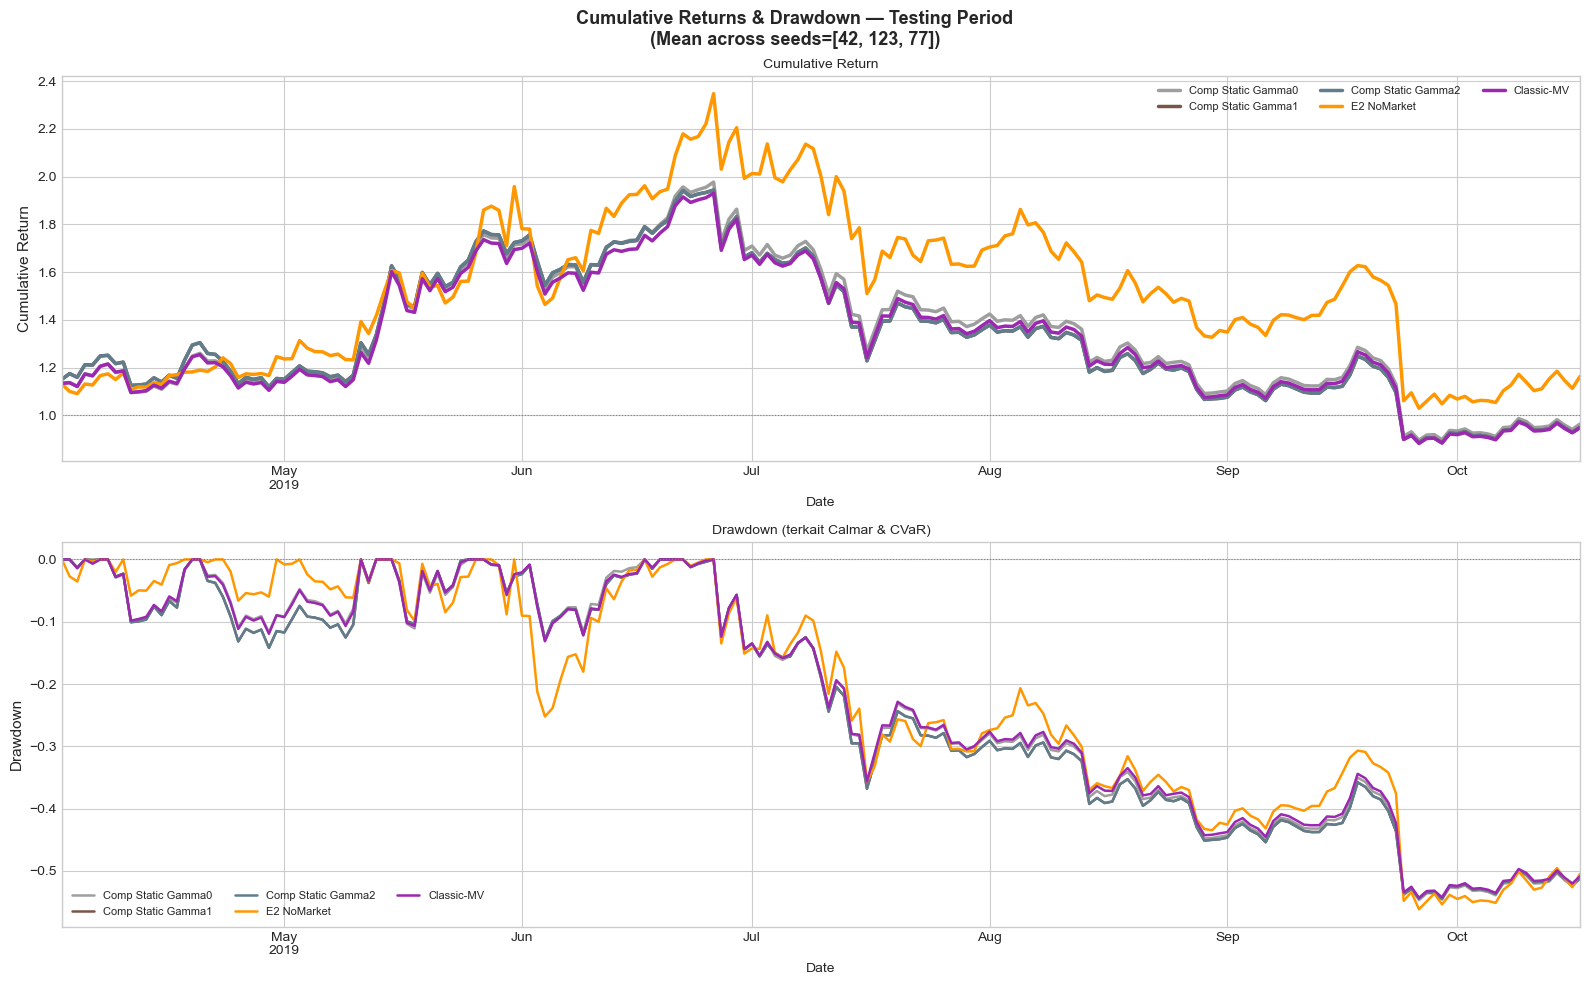

Saved: ablation_results_thesis/cumret_drawdown.png


In [44]:
# Vis 4: Cumulative Returns + Drawdown (Testing)
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=False)
fig.suptitle('Cumulative Returns & Drawdown — Testing Period\n'
             f'(Mean across seeds={SEEDS})',
             fontsize=13, fontweight='bold')

ax1 = axes[0]
for exp_id in exp_ids:
    cum = (1 + _mean_cumret(ablation_results, exp_id, 'test')).cumprod()
    lw  = 2.5 if exp_id in MAIN_EXPS else 1.2
    ls  = '-'  if exp_id in MAIN_EXPS else '--'
    cum.plot(ax=ax1, label=exp_id.replace('_', ' '),
             color=ABLATION_COLORS.get(exp_id, '#888'), linewidth=lw, linestyle=ls)
ax1.axhline(1.0, color='gray', linestyle=':', linewidth=0.8)
ax1.set_ylabel('Cumulative Return', fontsize=11)
ax1.set_title('Cumulative Return', fontsize=10)
ax1.legend(fontsize=8, ncol=3)

ax2 = axes[1]
for exp_id in plot_main_exps:
    mean_ret = _mean_cumret(ablation_results, exp_id, 'test')
    drawdown, _ = _compute_drawdown(mean_ret.values)
    pd.Series(drawdown, index=mean_ret.index).plot(
        ax=ax2, label=exp_id.replace('_', ' '),
        color=ABLATION_COLORS.get(exp_id, '#888'), linewidth=1.8
    )
ax2.axhline(0, color='gray', linestyle=':', linewidth=0.8)
ax2.set_ylabel('Drawdown', fontsize=11)
ax2.set_title('Drawdown (terkait Calmar & CVaR)', fontsize=10)
ax2.legend(fontsize=8, ncol=3)

plt.tight_layout()
plt.savefig('ablation_results_thesis/cumret_drawdown.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ablation_results_thesis/cumret_drawdown.png')


## Phase 14: Final Dashboard Tesis

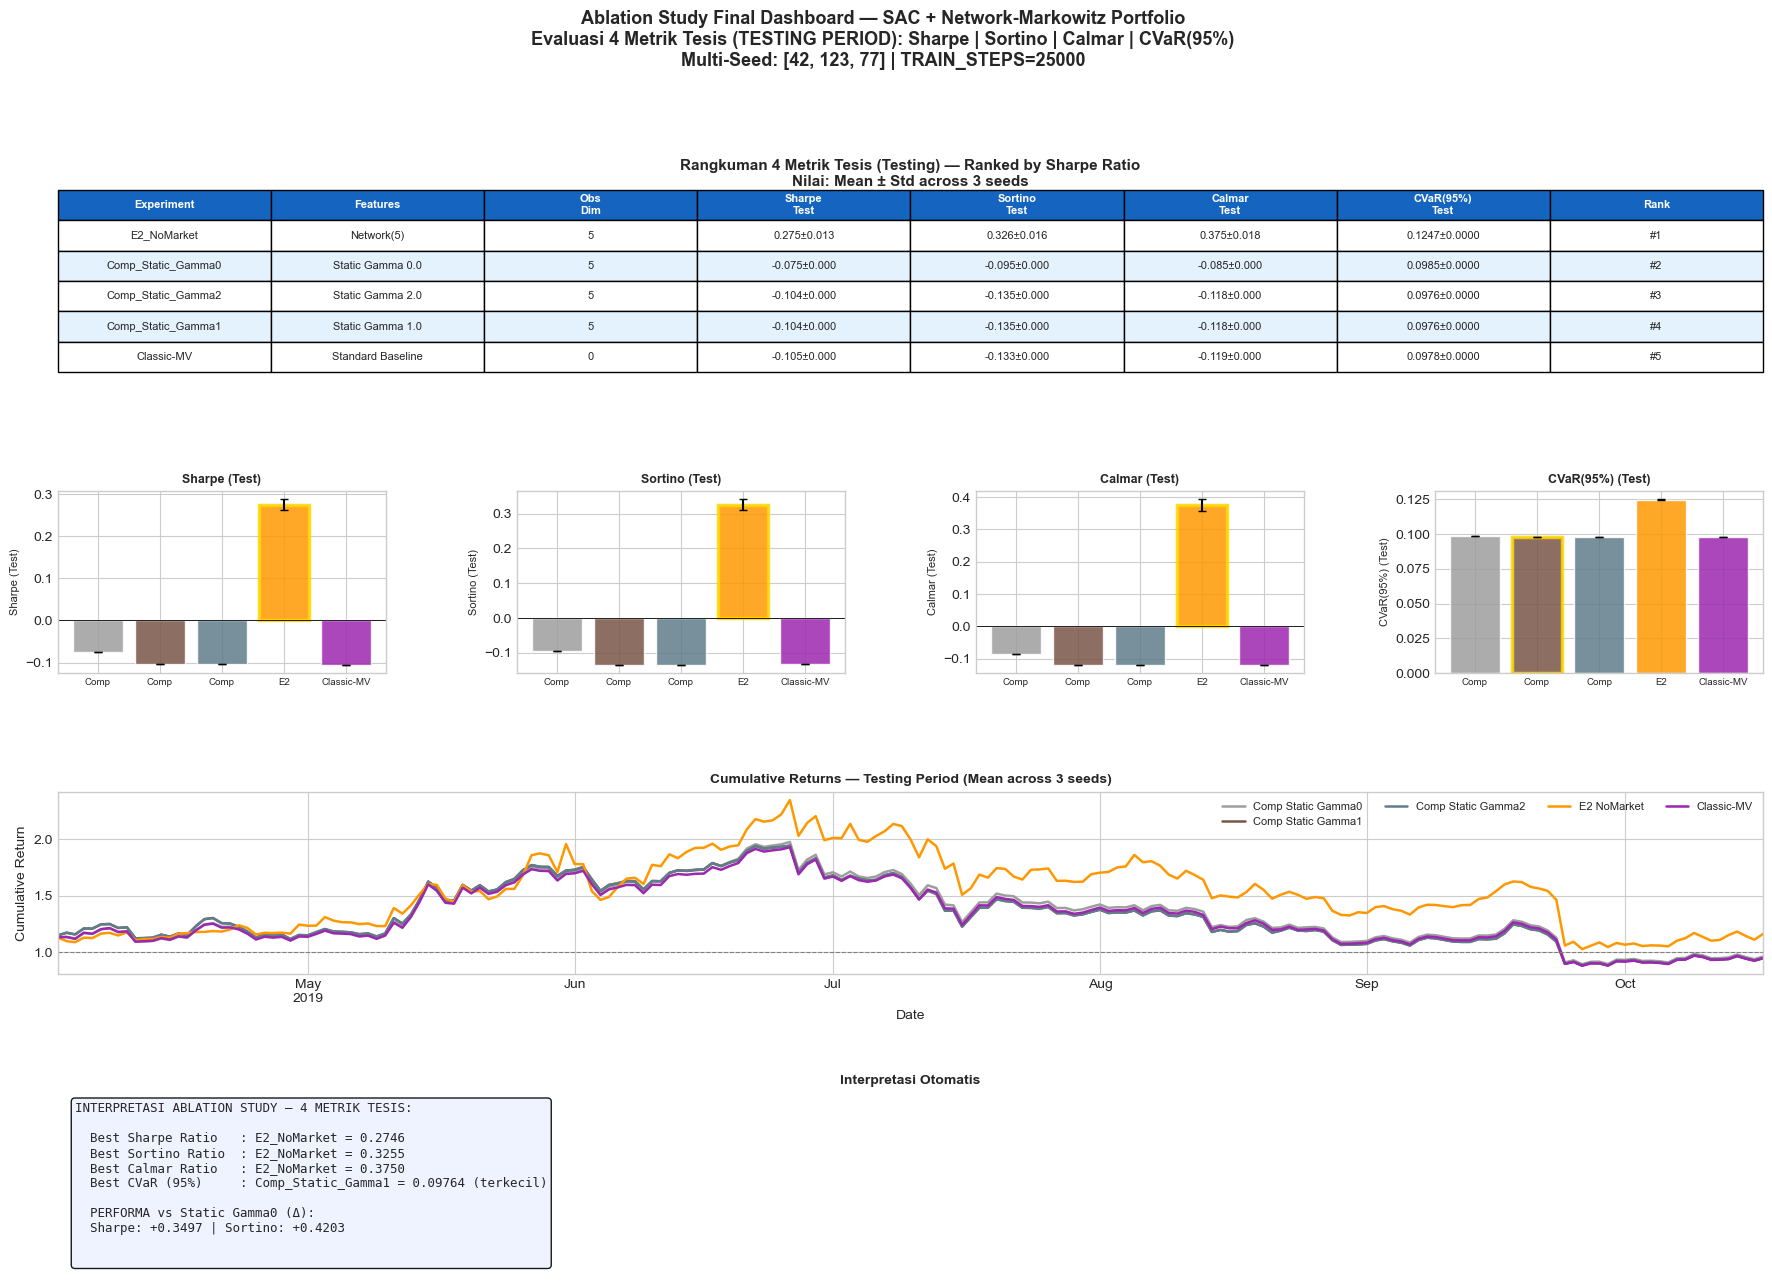

Saved: ablation_results_thesis/final_dashboard_test_4metrics.png


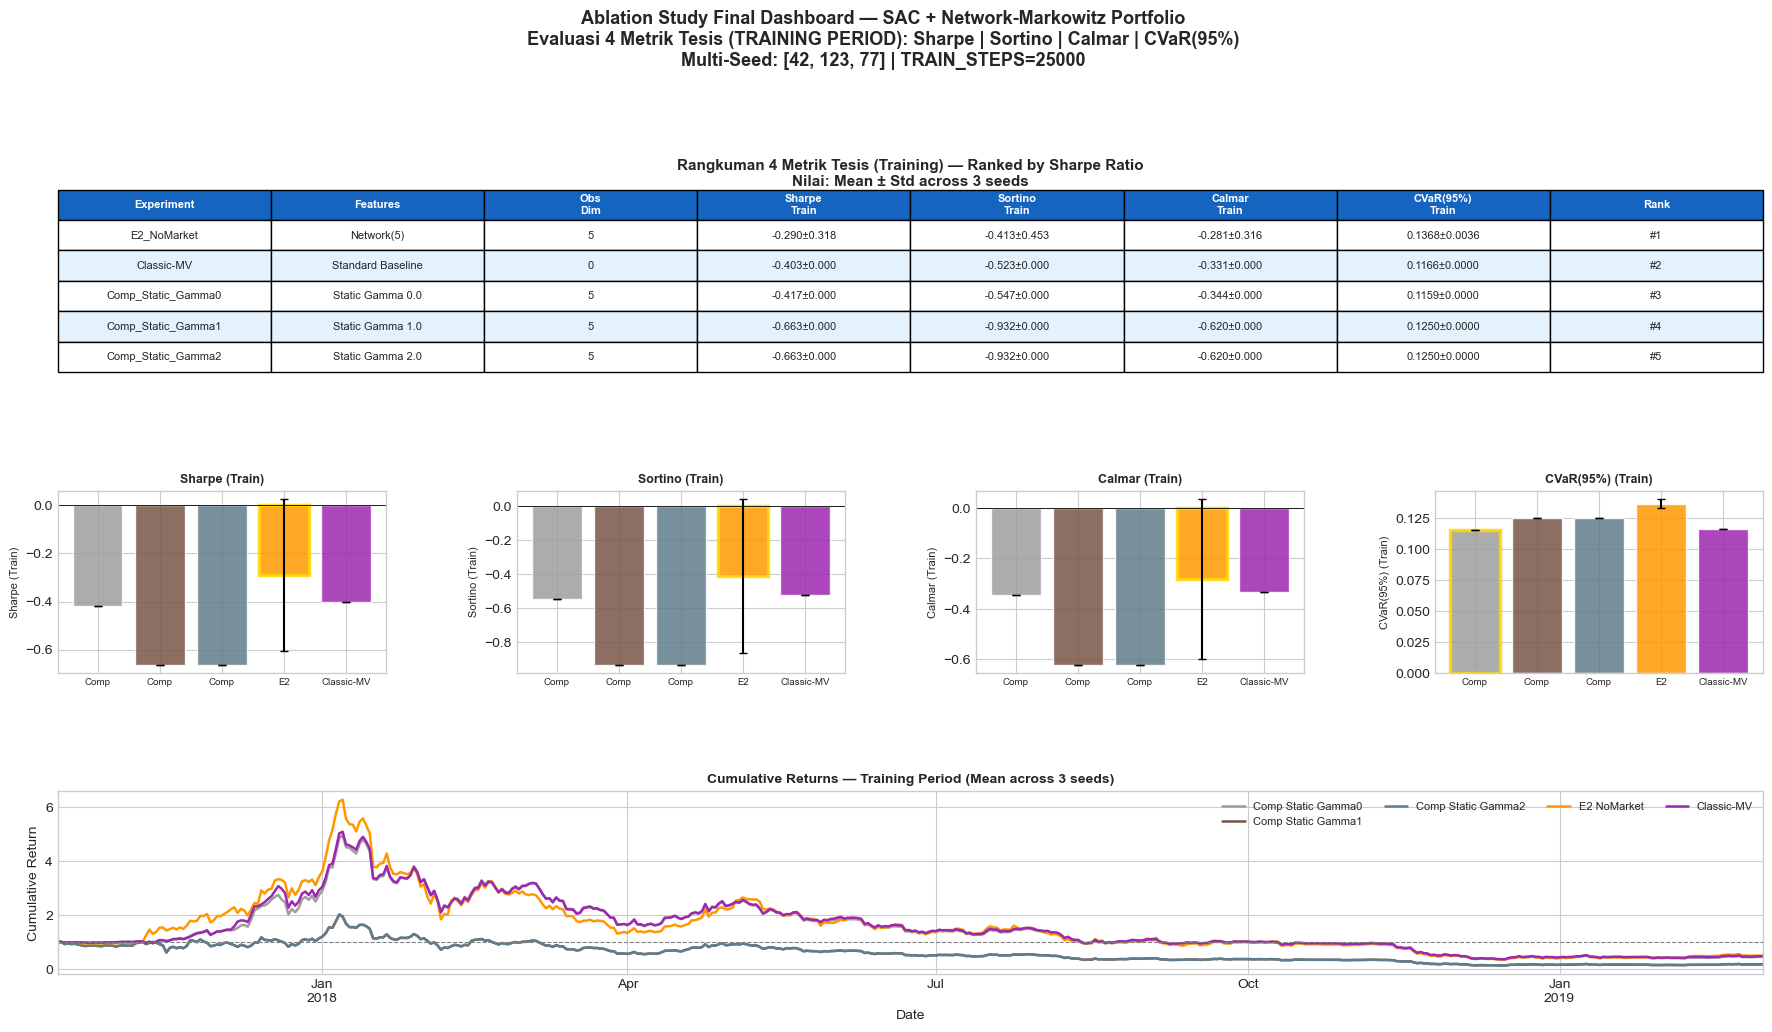

Saved: ablation_results_thesis/final_dashboard_train_4metrics.png

✅ Ablation Study THESIS-READY Selesai!
Outputs saved to ablation_results_thesis/:
  - ablation_summary_4metrics.csv
  - statistical_tests.csv
  - walkforward_results.csv
  - walkforward_robustness.csv
  - feature_correlation.png
  - learning_curves.png
  - 4metrics_bar.png
  - 4metrics_heatmap.png
  - 4metrics_radar.png
  - cumret_drawdown.png
  - walkforward_robustness.png
  - final_dashboard_test_4metrics.png
  - final_dashboard_train_4metrics.png


In [45]:
def plot_dashboard(period, ablation_results, summary_df, exp_ids, colors):
    period_lower = period.lower()
    period_label = 'Testing' if period == 'Test' else 'Training'

    fig = plt.figure(figsize=(22, 18))
    fig.suptitle(
        f'Ablation Study Final Dashboard — SAC + Network-Markowitz Portfolio\n'
        f'Evaluasi 4 Metrik Tesis ({period_label.upper()} PERIOD): '
        'Sharpe | Sortino | Calmar | CVaR(95%)\n'
        f'Multi-Seed: {SEEDS} | TRAIN_STEPS={TRAIN_STEPS}',
        fontsize=13, fontweight='bold', y=0.98
    )
    gs = gridspec.GridSpec(5, 4, figure=fig, hspace=0.65, wspace=0.4)

    # Panel 1: Summary Table
    ax_tbl = fig.add_subplot(gs[0, :])
    ax_tbl.axis('off')

    sort_col = f'SharpeRatio_{period}_Mean'
    ranked_df = summary_df.sort_values(sort_col, ascending=False)

    period_short = period[:5]
    col_labels = [
        'Experiment', 'Features', 'Obs\nDim',
        f'Sharpe\n{period_short}', f'Sortino\n{period_short}',
        f'Calmar\n{period_short}', f'CVaR(95%)\n{period_short}', 'Rank'
    ]
    tbl_data = []
    for rank, (exp_id, row) in enumerate(ranked_df.iterrows(), 1):
        p = period
        tbl_data.append([
            exp_id,
            row['Features'],
            int(row['Obs Dim']),
            f"{row[f'SharpeRatio_{p}_Mean']:.3f}±{row[f'SharpeRatio_{p}_Std']:.3f}",
            f"{row[f'SortinoRatio_{p}_Mean']:.3f}±{row[f'SortinoRatio_{p}_Std']:.3f}",
            f"{row[f'CalmarRatio_{p}_Mean']:.3f}±{row[f'CalmarRatio_{p}_Std']:.3f}",
            f"{row[f'CVaR95pct_{p}_Mean']:.4f}±{row[f'CVaR95pct_{p}_Std']:.4f}",
            f'#{rank}'
        ])

    tbl = ax_tbl.table(cellText=tbl_data, colLabels=col_labels,
                       cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
    _style_table(tbl, col_labels, len(tbl_data))
    ax_tbl.set_title(
        f'Rangkuman 4 Metrik Tesis ({period_label}) — Ranked by Sharpe Ratio\n'
        f'Nilai: Mean ± Std across {len(SEEDS)} seeds',
        fontsize=11, fontweight='bold', pad=3
    )

    # Panel 2-5: Bar chart per metrik
    metric_panels = [
        (f'SharpeRatio_{period}_Mean',  f'SharpeRatio_{period}_Std',  f'Sharpe ({period_short})',  False, gs[1, 0]),
        (f'SortinoRatio_{period}_Mean', f'SortinoRatio_{period}_Std', f'Sortino ({period_short})', False, gs[1, 1]),
        (f'CalmarRatio_{period}_Mean',  f'CalmarRatio_{period}_Std',  f'Calmar ({period_short})',  False, gs[1, 2]),
        (f'CVaR95pct_{period}_Mean',    f'CVaR95pct_{period}_Std',    f'CVaR(95%) ({period_short})', True, gs[1, 3]),
    ]
    for mean_col, std_col, label, lower_better, gs_pos in metric_panels:
        ax = fig.add_subplot(gs_pos)
        _plot_metric_bars(ax, summary_df, exp_ids, colors, mean_col, std_col, label, lower_better)

    # Panel 6: Cumulative Returns
    ax_cum = fig.add_subplot(gs[2, :])
    for exp_id in plot_main_exps:
        mean_ret = _mean_cumret(ablation_results, exp_id, period_lower)
        (1 + mean_ret).cumprod().plot(
            ax=ax_cum, label=exp_id.replace('_', ' '),
            color=ABLATION_COLORS.get(exp_id, '#888'), linewidth=1.8
        )
    ax_cum.axhline(1.0, color='gray', linestyle='--', linewidth=0.8)
    ax_cum.set_title(
        f'Cumulative Returns — {period_label} Period (Mean across {len(SEEDS)} seeds)',
        fontsize=10, fontweight='bold'
    )
    ax_cum.set_ylabel('Cumulative Return')
    ax_cum.legend(fontsize=8, ncol=4)

    # Panel 7: Statistical test summary (Testing only)
    if period == 'Test' and 'stat_df' in dir():
        ax_stat = fig.add_subplot(gs[3, :2])
        ax_stat.axis('off')
        sig_results = stat_df[stat_df['Significant'] == True]
        stat_text = f'UJI STATISTIK: E2_NoMarket vs Baseline\n(α={STAT_ALPHA}, Wilcoxon Signed-Rank)\n\n'
        for _, row in stat_df[stat_df['Compared_to'].isin(comparison_ids)].iterrows():
            mark = '✓*' if row['Significant'] else '  '
            stat_text += f'{mark} vs {row["Compared_to"]}: p={row["p_value"]:.4f}\n'
        ax_stat.text(0.01, 0.95, stat_text, transform=ax_stat.transAxes,
                     fontsize=9, verticalalignment='top', fontfamily='monospace',
                     bbox=dict(boxstyle='round', facecolor='#E8F5E9', alpha=0.9))
        ax_stat.set_title('Ringkasan Uji Statistik', fontsize=10, fontweight='bold')

    # Panel 8: Interpretasi Otomatis
    if period == 'Test':
        ax_interp = fig.add_subplot(gs[3, 2:] if 'stat_df' in dir() else gs[3, :])
        ax_interp.axis('off')

        best_sharpe  = summary_df['SharpeRatio_Test_Mean'].idxmax()
        best_sortino = summary_df['SortinoRatio_Test_Mean'].idxmax()
        best_calmar  = summary_df['CalmarRatio_Test_Mean'].idxmax()
        best_cvar    = summary_df['CVaR95pct_Test_Mean'].idxmin()

        base = {m: summary_df.loc['Comp_Static_Gamma0', f'{METRIC_KEY[m]}_Test_Mean']
                for m in FOUR_METRICS}

        def delta(exp, m):
            return summary_df.loc[exp, f'{METRIC_KEY[m]}_Test_Mean'] - base[m]

        interpretasi = (
            'INTERPRETASI ABLATION STUDY — 4 METRIK TESIS:\n\n'
            f'  Best Sharpe Ratio   : {best_sharpe} = {summary_df.loc[best_sharpe,  "SharpeRatio_Test_Mean"]:.4f}\n'
            f'  Best Sortino Ratio  : {best_sortino} = {summary_df.loc[best_sortino, "SortinoRatio_Test_Mean"]:.4f}\n'
            f'  Best Calmar Ratio   : {best_calmar} = {summary_df.loc[best_calmar,  "CalmarRatio_Test_Mean"]:.4f}\n'
            f'  Best CVaR (95%)     : {best_cvar} = {summary_df.loc[best_cvar, "CVaR95pct_Test_Mean"]:.5f} (terkecil)\n\n'
            '  PERFORMA vs Static Gamma0 (Δ):\n'
            f'  Sharpe: {delta("E2_NoMarket","Sharpe Ratio"):+.4f} | Sortino: {delta("E2_NoMarket","Sortino Ratio"):+.4f}\n\n'
            ''
        )

        ax_interp.text(0.01, 0.95, interpretasi, transform=ax_interp.transAxes,
                       fontsize=9, verticalalignment='top', fontfamily='monospace',
                       bbox=dict(boxstyle='round', facecolor='#EEF2FF', alpha=0.9))
        ax_interp.set_title('Interpretasi Otomatis', fontsize=10, fontweight='bold')

    fname = f'ablation_results_thesis/final_dashboard_{period_lower}_4metrics.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')


plot_dashboard('Test',  ablation_results, summary_df, exp_ids, colors)
plot_dashboard('Train', ablation_results, summary_df, exp_ids, colors)

print('\n✅ Ablation Study THESIS-READY Selesai!')
print('Outputs saved to ablation_results_thesis/:')
for f in [
    'ablation_summary_4metrics.csv',
    'statistical_tests.csv',
    'walkforward_results.csv',
    'walkforward_robustness.csv',
    'feature_correlation.png',
    'learning_curves.png',
    '4metrics_bar.png',
    '4metrics_heatmap.png',
    '4metrics_radar.png',
    'cumret_drawdown.png',
    'walkforward_robustness.png',
    'final_dashboard_test_4metrics.png',
    'final_dashboard_train_4metrics.png',
]:
    print(f'  - {f}')


## Phase XAI: Explainable AI — Policy SAC E2_NoMarket

Tiga metode XAI untuk menjelaskan keputusan policy SAC:

| Metode | Pertanyaan | Library |
|---|---|---|
| **SHAP** | Fitur mana paling berpengaruh & arahnya? | `shap` |
| **Permutation Importance** | Dampak jika satu fitur diacak? | built-in |
| **Partial Dependence Plot** | Gamma output vs perubahan satu fitur? | built-in |

> **Catatan**: Jalankan setelah semua Phase sebelumnya selesai. SHAP butuh `pip install shap`.

In [46]:
# ================================================================
# PHASE XAI — 1. Setup: Load model & kumpulkan observations
# ================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from stable_baselines3 import SAC

SEED_FOR_XAI = 42
model_xai = SAC.load(f'ablation_E2_NoMarket_seed{SEED_FOR_XAI}')

FEATURE_NAMES = [
    'Cent.Std x10',
    'Cent.Mean x10',
    'MST.Dist x0.1',
    'Max.Cent',
    'Net.Density'
]

# ---- Kumpulkan observations & gamma dari test set ----
obs_list   = []
gamma_list = []

for i in range(SET_WINDOW, len(ret_test)):
    win = ret_test.iloc[i - SET_WINDOW : i]
    obs_raw, _, _ = build_observation(win, ABLATION_CONFIGS['E2_NoMarket'])
    obs_list.append(obs_raw)
    action, _ = model_xai.predict(obs_raw, deterministic=True)
    gamma_list.append(float(np.clip(action[0], -5.0, 5.0)) + GAMMA_CENTER)

obs_array   = np.array(obs_list)    # shape: (N, 5)
gamma_array = np.array(gamma_list)  # shape: (N,)

print(f'Observations collected: {len(obs_array)}')
print(f'Gamma range  : [{gamma_array.min():.3f}, {gamma_array.max():.3f}]')
print(f'Gamma mean   : {gamma_array.mean():.3f}')


Observations collected: 199
Gamma range  : [-4.147, -3.450]
Gamma mean   : -3.684


  0%|          | 0/100 [00:00<?, ?it/s]

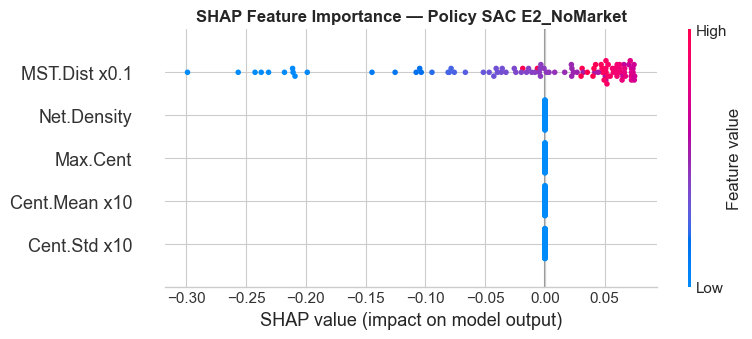

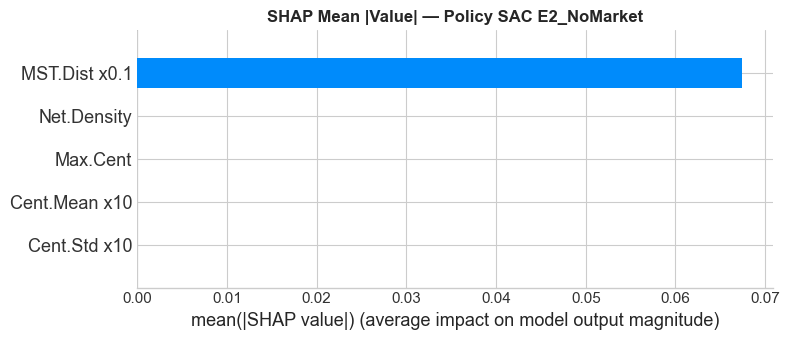

SHAP plots saved.


In [47]:
# ================================================================
# PHASE XAI — 2. SHAP Explanation
# ================================================================
try:
    import shap

    def predict_gamma(obs_batch):
        results = []
        for obs in obs_batch:
            action, _ = model_xai.predict(obs.astype(np.float32), deterministic=True)
            results.append(float(np.clip(action[0], -5.0, 5.0)) + GAMMA_CENTER)
        return np.array(results)

    background  = obs_array[:50]
    explainer   = shap.KernelExplainer(predict_gamma, background)
    shap_values = explainer.shap_values(obs_array[:100], nsamples=100)

    # --- Summary Plot ---
    fig = plt.figure(figsize=(10, 5))
    shap.summary_plot(shap_values, obs_array[:100],
                      feature_names=FEATURE_NAMES, show=False)
    plt.title('SHAP Feature Importance — Policy SAC E2_NoMarket',
              fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('ablation_results_thesis/xai_shap_summary.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    # --- Bar Plot ---
    fig = plt.figure(figsize=(8, 4))
    shap.summary_plot(shap_values, obs_array[:100],
                      feature_names=FEATURE_NAMES,
                      plot_type='bar', show=False)
    plt.title('SHAP Mean |Value| — Policy SAC E2_NoMarket',
              fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('ablation_results_thesis/xai_shap_bar.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print('SHAP plots saved.')

except ImportError:
    print('[WARNING] shap tidak terinstall — lewati SHAP analysis.')
    print('  Jalankan: pip install shap  lalu restart kernel & re-run.')


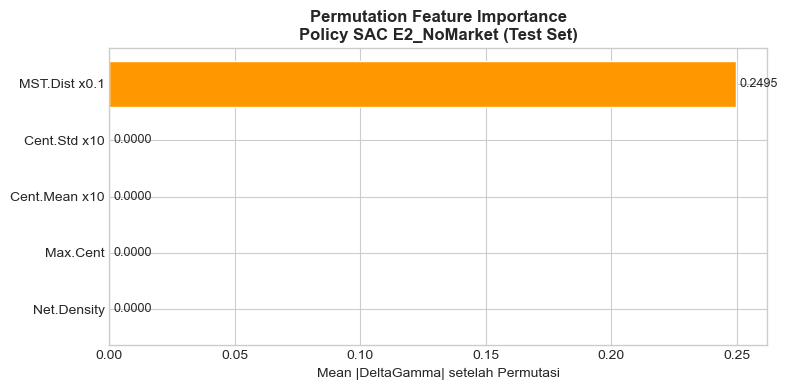

Permutation Importance saved.

Ranking Fitur (paling berpengaruh ke paling tidak):
  #1  MST.Dist x0.1        : 0.24951
  #2  Cent.Std x10         : 0.00000
  #3  Cent.Mean x10        : 0.00000
  #4  Max.Cent             : 0.00000
  #5  Net.Density          : 0.00000


In [48]:
# ================================================================
# PHASE XAI — 3. Permutation Feature Importance
# ================================================================
np.random.seed(42)
baseline_gamma = gamma_array.copy()
importance = {}

for fi, fname in enumerate(FEATURE_NAMES):
    obs_shuffled = obs_array.copy()
    idx = np.random.permutation(len(obs_shuffled))
    obs_shuffled[:, fi] = obs_shuffled[idx, fi]

    gamma_shuffled = []
    for obs in obs_shuffled:
        action, _ = model_xai.predict(obs.astype(np.float32), deterministic=True)
        gamma_shuffled.append(float(np.clip(action[0], -5.0, 5.0)) + GAMMA_CENTER)
    gamma_shuffled = np.array(gamma_shuffled)
    importance[fname] = np.mean(np.abs(baseline_gamma - gamma_shuffled))

sorted_imp   = sorted(importance.items(), key=lambda x: x[1], reverse=True)
names_sorted = [x[0] for x in sorted_imp]
vals_sorted  = [x[1] for x in sorted_imp]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(names_sorted, vals_sorted, color='#FF9800', edgecolor='white')
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
ax.set_xlabel('Mean |DeltaGamma| setelah Permutasi', fontsize=10)
ax.set_title('Permutation Feature Importance\nPolicy SAC E2_NoMarket (Test Set)',
             fontsize=12, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('ablation_results_thesis/xai_permutation_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()

print('Permutation Importance saved.')
print('\nRanking Fitur (paling berpengaruh ke paling tidak):')
for rank, (n, v) in enumerate(sorted_imp, 1):
    print(f'  #{rank}  {n:<20s} : {v:.5f}')


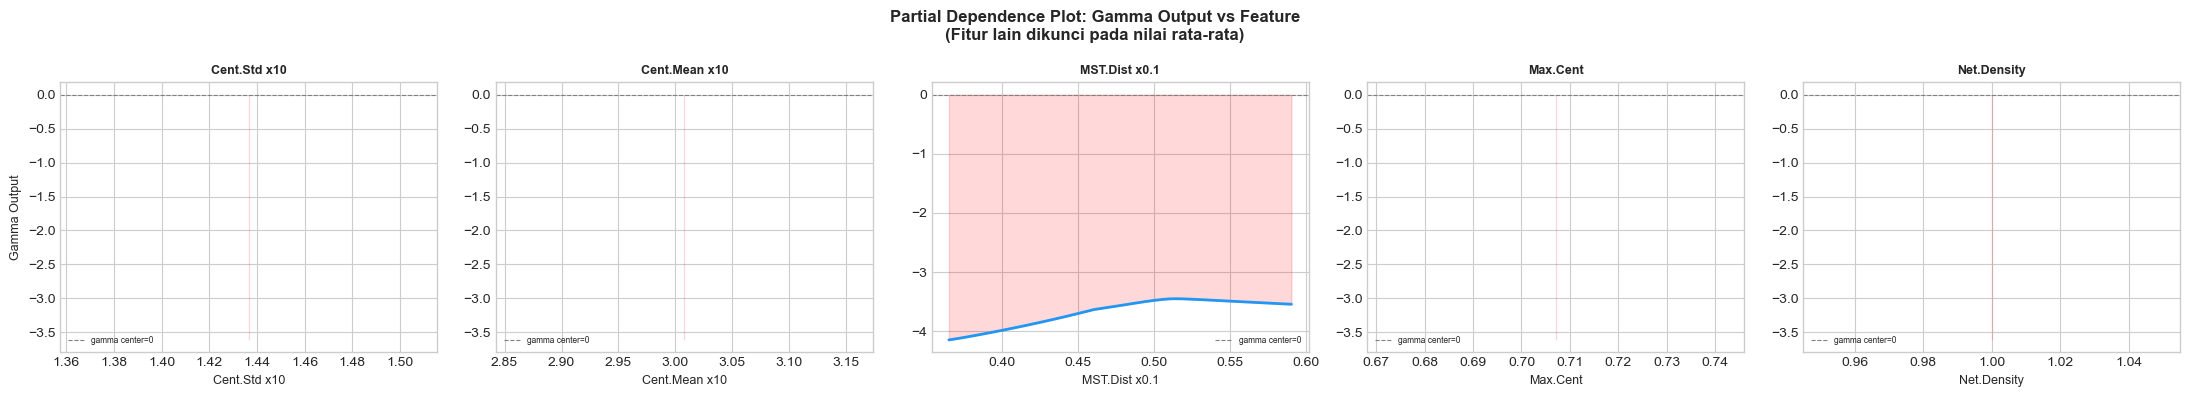

PDP saved.


In [49]:
# ================================================================
# PHASE XAI — 4. Partial Dependence Plots (PDP)
# ================================================================
mean_obs = obs_array.mean(axis=0)
N_POINTS = 60

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
fig.suptitle(
    'Partial Dependence Plot: Gamma Output vs Feature\n'
    '(Fitur lain dikunci pada nilai rata-rata)',
    fontsize=12, fontweight='bold'
)

for fi, (fname, ax) in enumerate(zip(FEATURE_NAMES, axes)):
    f_min   = obs_array[:, fi].min()
    f_max   = obs_array[:, fi].max()
    f_range = np.linspace(f_min, f_max, N_POINTS)

    gamma_pdp = []
    for fval in f_range:
        obs_temp = mean_obs.copy()
        obs_temp[fi] = fval
        action, _ = model_xai.predict(obs_temp.astype(np.float32), deterministic=True)
        gamma_pdp.append(float(np.clip(action[0], -5.0, 5.0)) + GAMMA_CENTER)

    ax.plot(f_range, gamma_pdp, color='#2196F3', linewidth=2)
    ax.axhline(GAMMA_CENTER, color='gray', linestyle='--', linewidth=0.8,
               label=f'gamma center={GAMMA_CENTER}')
    ax.fill_between(f_range, gamma_pdp, GAMMA_CENTER,
                    where=[g > GAMMA_CENTER for g in gamma_pdp],
                    alpha=0.15, color='green')
    ax.fill_between(f_range, gamma_pdp, GAMMA_CENTER,
                    where=[g <= GAMMA_CENTER for g in gamma_pdp],
                    alpha=0.15, color='red')
    ax.set_xlabel(fname, fontsize=9)
    if fi == 0:
        ax.set_ylabel('Gamma Output', fontsize=9)
    ax.set_title(fname, fontsize=9, fontweight='bold')
    ax.legend(fontsize=6)

plt.tight_layout()
plt.savefig('ablation_results_thesis/xai_pdp.png', dpi=150, bbox_inches='tight')
plt.show()
print('PDP saved.')


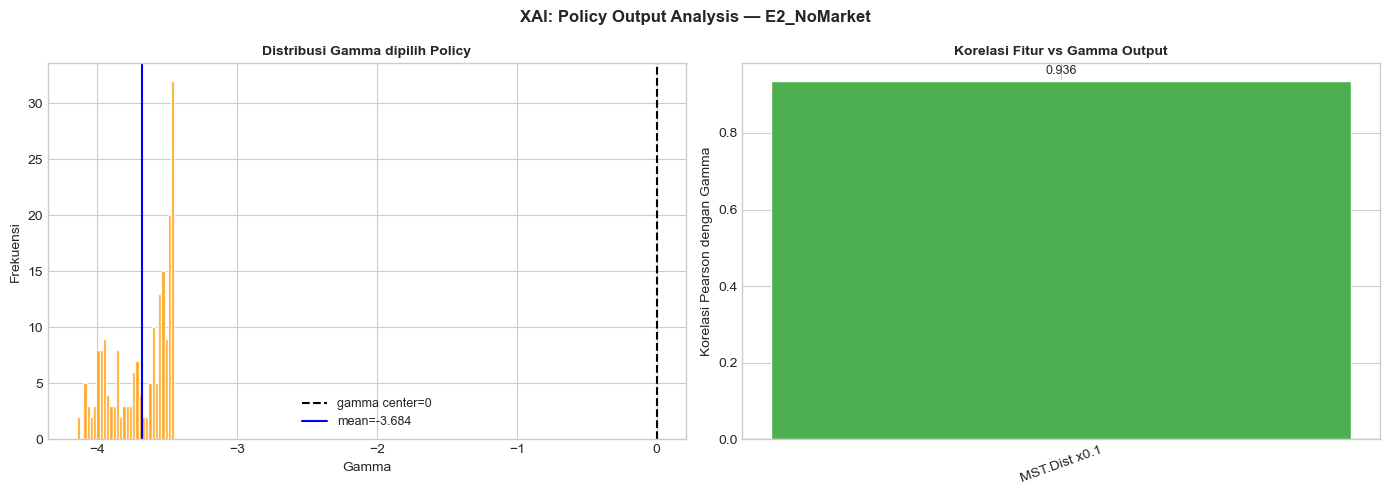

Gamma Analysis saved.

=== Ringkasan XAI ===
  Total observasi   : 199
  Gamma min/max/mean: -4.147 / -3.450 / -3.684

  Korelasi Fitur vs Gamma:
    Cent.Std x10        : +nan
    Cent.Mean x10       : +nan
    MST.Dist x0.1       : +0.936
    Max.Cent            : +nan
    Net.Density         : +nan

 XAI Analysis Selesai!
Outputs tersimpan di ablation_results_thesis/:
  - xai_shap_summary.png
  - xai_shap_bar.png
  - xai_permutation_importance.png
  - xai_pdp.png
  - xai_gamma_analysis.png


In [50]:
# ================================================================
# PHASE XAI — 5. Gamma Distribution & Feature Correlation
# ================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('XAI: Policy Output Analysis — E2_NoMarket',
             fontsize=12, fontweight='bold')

# --- (a) Distribusi Gamma ---
ax = axes[0]
ax.hist(gamma_array, bins=30, color='#FF9800', edgecolor='white', alpha=0.85)
ax.axvline(GAMMA_CENTER, color='black', linestyle='--', linewidth=1.5,
           label=f'gamma center={GAMMA_CENTER}')
ax.axvline(gamma_array.mean(), color='blue', linestyle='-', linewidth=1.5,
           label=f'mean={gamma_array.mean():.3f}')
ax.set_xlabel('Gamma', fontsize=10)
ax.set_ylabel('Frekuensi', fontsize=10)
ax.set_title('Distribusi Gamma dipilih Policy', fontsize=10, fontweight='bold')
ax.legend(fontsize=9)

# --- (b) Korelasi fitur vs gamma ---
ax = axes[1]
corr_vals   = [np.corrcoef(obs_array[:, fi], gamma_array)[0, 1]
               for fi in range(len(FEATURE_NAMES))]
colors_corr = ['#4CAF50' if c > 0 else '#F44336' for c in corr_vals]
bars = ax.bar(FEATURE_NAMES, corr_vals, color=colors_corr, edgecolor='white')
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Korelasi Pearson dengan Gamma', fontsize=10)
ax.set_title('Korelasi Fitur vs Gamma Output', fontsize=10, fontweight='bold')
ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('ablation_results_thesis/xai_gamma_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()

print('Gamma Analysis saved.')
print('\n=== Ringkasan XAI ===')
print(f'  Total observasi   : {len(obs_array)}')
print(f'  Gamma min/max/mean: {gamma_array.min():.3f} / {gamma_array.max():.3f} / {gamma_array.mean():.3f}')
print('\n  Korelasi Fitur vs Gamma:')
for fn, cv in zip(FEATURE_NAMES, corr_vals):
    print(f'    {fn:<20s}: {cv:+.3f}')
print('\n XAI Analysis Selesai!')
print('Outputs tersimpan di ablation_results_thesis/:')
for f in ['xai_shap_summary.png', 'xai_shap_bar.png',
          'xai_permutation_importance.png', 'xai_pdp.png',
          'xai_gamma_analysis.png']:
    print(f'  - {f}')
